# Generalized E3SMLE and CESM-SMYLE Global RMSE Skill Maps

This notebook computes and plots seasonal skill for `TREFHT`, `PRECT`, or `PSL` using the same workflow.

Change only one line in the configuration cell below:

```python
# field = "TREFHT"  # surface air temperature
# field = "PRECT" # precipitation
# field = "PSL"   # sea-level pressure
```

Variable-specific observation product, observation variable name, unit conversion, labels, and cache filenames are handled through `VAR_CONFIG`.


In [43]:
%load_ext autoreload
%autoreload 2
import os
from pathlib import Path
import xarray as xr 
import numpy as np  
import cftime
import copy
import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import xesmf as xe
import xskillscore as xs
%matplotlib inline

# import ESP-Lab modules
#from esp_lab import data_access_smyle.py as data_access
from esp_lab import data_access_e3sm as data_access
from esp_lab import data_access_obs as obs_access
from esp_lab import stats

# import plotting and other utilities from esp_lab.utils (formerly SMYLEutils)
from esp_lab.utils import calendar_utils as cal
from esp_lab.utils import mapplot_utils as maps
from esp_lab.utils import colorbar_utils as cbars
from esp_lab.utils import regrid_utils as regrid
from esp_lab.utils import mov_utils as mov

# Default figure output directory for this HPC environment.
FIGURE_OUTDIR = Path("/global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag")
FIGURE_OUTDIR.mkdir(parents=True, exist_ok=True)


def figure_filename(*parts, ext="png"):
    """Build consistent, readable lowercase snake_case figure filenames."""
    import re

    clean_parts = ["fig"]
    for part in parts:
        if part is None:
            continue
        text = str(part).strip()
        if not text:
            continue
        text = re.sub(r"[^A-Za-z0-9]+", "_", text).strip("_").lower()
        if text:
            clean_parts.append(text)

    suffix = ext.lstrip(".").lower()
    return "_".join(clean_parts) + f".{suffix}"


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [44]:
import dask
from dask.distributed import (
    wait,
    get_client
)
dask.__version__

'2026.3.0'

## Preprocessing:  Data I/O using Dask

### Create Dask Cluster

In [ ]:
def get_ClusterClient(cluster_type='local', workers=4):
    """
    Create a Dask Cluster and Client based on the machine environment.
    cluster_type options: 'local', 'casper_pbs', 'slurm'
    """
    import dask
    from dask.distributed import Client
    
    # Optional global dask config
    dask.config.set({'array.slicing.split_large_chunks': True})

    if cluster_type == 'casper_pbs':
        # Specific to NCAR's Casper machine
        from dask_jobqueue import PBSCluster
        cluster = PBSCluster(
            cores=1,
            memory='20GB',
            processes=1,
            queue='casper',
            resource_spec='select=1:ncpus=1:mem=20GB',
            project='NCGD0011',
            walltime='02:00:00',
            interface='ib0'
        )
        dask.config.set({
            'distributed.dashboard.link':
            'https://jupyterhub.hpc.ucar.edu/stable/user/{USER}/proxy/{port}/status'
        })
        client = Client(cluster)
        cluster.scale(30)
        
    elif cluster_type == 'slurm':
        from dask_jobqueue import SLURMCluster
        cluster = SLURMCluster(
            cores=4,
            processes=1,
            memory="16GB",
            walltime="02:00:00"
            # queue="compute", 
            # project="my_project" 
        )
        client = Client(cluster)
        cluster.scale(workers)
        
    elif cluster_type == 'local':
        from dask.distributed import LocalCluster

        # Do not launch the production worker count on the Jupyter host.
        # Thirty local worker processes can exhaust memory and kill the kernel.
        local_worker_cap = int(os.environ.get("DASK_LOCAL_WORKERS", "2"))
        local_workers = max(1, min(workers, local_worker_cap))
        local_memory_limit = os.environ.get("DASK_LOCAL_MEMORY_LIMIT", "4GB")
        cluster = LocalCluster(
            n_workers=local_workers,
            threads_per_worker=1,
            processes=True,
            memory_limit=local_memory_limit,
            dashboard_address=None,
        )
        client = Client(cluster)
        print(
            f"Local Dask cluster: {local_workers} workers, "
            f"{local_memory_limit} limit per worker"
        )
        
    else:
        raise ValueError(f"Unknown cluster_type: {cluster_type}")

    return cluster, client

# Set this to 'casper_pbs' when on NCAR Casper, or 'local' on your PC
machine_env = os.environ.get('CLUSTER_TYPE', 'local') 

try:
    client = get_client()
    print(client)
except ValueError:
    print("No active client")
try:
    client.close()
    cluster.close()
except:
    pass

cluster, client = get_ClusterClient(cluster_type=machine_env, workers=30)

<Client: 'tcp://127.0.0.1:37839' processes=2 threads=2, memory=7.45 GiB>


/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 46829 instead
  warnings.warn(


Local Dask cluster: 2 workers, 4GB limit per worker


2026-06-19 17:29:36,144 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 28a9fcba60b0189ecf360834b082b66c initialized by task ('rechunk-merge-rechunk-transfer-e67abbcc794233df3b8ab3d95ac6ca7b', 0, 2, 0, 0, 2, 0) executed on worker tcp://127.0.0.1:41039
2026-06-19 17:29:36,180 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle aa83b68a045c234d8a43b862a2eccf85 initialized by task ('rechunk-merge-rechunk-transfer-e67abbcc794233df3b8ab3d95ac6ca7b', 0, 1, 1, 0, 1, 1) executed on worker tcp://127.0.0.1:35271
2026-06-19 17:29:36,208 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 5eaa8e05b52e177869d53d7ccb09570e initialized by task ('rechunk-merge-rechunk-transfer-e67abbcc794233df3b8ab3d95ac6ca7b', 0, 0, 0, 0, 0, 0) executed on worker tcp://127.0.0.1:41039
2026-06-19 17:29:36,331 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 6fade86bb62a94b799e50c4d2e94d24c initialized by task ('rechunk-merge-rechunk-transfer-e67abbcc794233df3b8ab3d95ac6ca7b', 0, 

In [46]:
cluster

LocalCluster(3cc05eca, 'tcp://127.0.0.1:36389', workers=2, threads=2, memory=7.45 GiB)

### Read in EAM monthly data; Convert to Seasonal averages (DJF, MAM, JJA, SON)
- Chosen field is returned as a dask array with leading dimensions of Y (initialization year), M (ensemble member), and L (lead season). For example, for November starts, L=1 corresponds to first DJF season.
- "time" which gives prediction verification time (centered time for a given season) is also dimensioned with (Y,L)

In [47]:
%%time
# -----------------------------------------------------------------------------
# Variable-driven setup
# -----------------------------------------------------------------------------
# Change this one line to switch diagnostics:
#   field = "TREFHT"  -> ERA5 tas, model/obs K -> degC
#   field = "PRECT"   -> GPCP PRECT, model m/s -> mm/day
#   field = "PSL"     -> ERA5 psl, model/obs Pa -> hPa
#field = "PRECT"
#field = "TREFHT"
field = "PSL"

def convert_kelvin_to_celsius(da):
    """Convert K to degC while preserving lazy evaluation."""
    da = da - 273.15
    da.attrs["units"] = r"$^\circ$C"
    return da


def convert_precip_mps_to_mmday(da):
    """Convert precipitation from m/s to mm/day while preserving lazy evaluation."""
    da = da * (1000.0 * 86400.0)
    da.attrs["units"] = "mm/day"
    return da


def convert_pa_to_hpa(da):
    """Convert pressure from Pa to hPa while preserving lazy evaluation."""
    da = da * 1.0e-2
    da.attrs["units"] = "hPa"
    return da


def no_unit_conversion(da, units=None):
    """Return a lazy copy and optionally standardize the unit attribute."""
    da = da * 1.0
    if units is not None:
        da.attrs["units"] = units
    return da


VAR_CONFIG = {
    "TREFHT": {
        "long_name": "2-m air temperature",
        "plot_name": "Surface air temperature",
        "obs_name": "ERA5",
        "obs_var": "tas",
        "obs_ys": "1979",
        "obs_ye": "2019",
        "model_convert": convert_kelvin_to_celsius,
        "smyle_convert": convert_kelvin_to_celsius,
        "obs_convert": convert_kelvin_to_celsius,
        "units": r"$^\circ$C",
    },
    "PRECT": {
        "long_name": "precipitation",
        "plot_name": "Precipitation",
        "obs_name": "GPCP_v2.3",
        "obs_var": "PRECT",
        "obs_ys": "1979",
        "obs_ye": "2017",
        "model_convert": convert_precip_mps_to_mmday,
        "smyle_convert": convert_precip_mps_to_mmday,
        # GPCP PRECT from this archive is already mm/day.
        "obs_convert": lambda da: no_unit_conversion(da, units="mm/day"),
        "units": "mm/day",
    },
    "PSL": {
        "long_name": "sea-level pressure",
        "plot_name": "Sea-level pressure",
        "obs_name": "ERA5",
        "obs_var": "psl",
        "obs_ys": "1979",
        "obs_ye": "2019",
        "model_convert": convert_pa_to_hpa,
        "smyle_convert": convert_pa_to_hpa,
        "obs_convert": convert_pa_to_hpa,
        "units": "hPa",
    },
}

if field not in VAR_CONFIG:
    raise ValueError(f"Unsupported field={field!r}. Available fields: {list(VAR_CONFIG)}")

cfg = VAR_CONFIG[field]

# Field-specific map colorbar configuration.
# `levels` control color boundaries; `ticks` control displayed labels.
MAP_COLORBAR_CONFIG = {
    "absolute_rmse": {
        "TREFHT": {"levels": [0, 0.5, 1, 1.5, 2, 2.5, 3],
                   "ticks": [0, 0.5, 1, 1.5, 2, 2.5, 3], "decimals": 1},
        "PRECT": {"levels": [0, 0.5, 1, 1.5, 2, 2.5, 3],
                  "ticks": [0, 0.5, 1, 1.5, 2, 2.5, 3], "decimals": 1},
        "PSL": {"levels": [0, 2, 4, 6, 8, 10, 12],
                "ticks": [0, 2, 4, 6, 8, 10, 12], "decimals": 1},
    },
    "normalized_rmse_difference": {
        "TREFHT": {"levels": [-0.5, -0.45, -0.4, -0.35, -0.3, -0.25,
                              -0.2, -0.15, -0.1, -0.05, 0,
                              0.05, 0.1, 0.15, 0.2, 0.25,
                              0.3, 0.35, 0.4, 0.45, 0.5],
                   "ticks": [-0.5, -0.25, 0, 0.25, 0.5], "decimals": 2},
        "PRECT": {"levels": [-0.5, -0.45, -0.4, -0.35, -0.3, -0.25,
                             -0.2, -0.15, -0.1, -0.05, 0,
                             0.05, 0.1, 0.15, 0.2, 0.25,
                             0.3, 0.35, 0.4, 0.45, 0.5],
                  "ticks": [-0.5, -0.25, 0, 0.25, 0.5], "decimals": 2},
        "PSL": {"levels": [-1.0, -0.9, -0.8, -0.7, -0.6, -0.5,
                           -0.4, -0.3, -0.2, -0.1, 0,
                           0.1, 0.2, 0.3, 0.4, 0.5,
                           0.6, 0.7, 0.8, 0.9, 1.0],
                "ticks": [-1.0, -0.5, 0, 0.5, 1.0], "decimals": 1},
    },
}


def map_colorbar_settings(plot_type, field):
    config = MAP_COLORBAR_CONFIG[plot_type][field]
    levels = np.asarray(config["levels"], dtype=float)
    ticks = np.asarray(config["ticks"], dtype=float)
    steps = np.diff(levels)
    if levels.ndim != 1 or levels.size < 2 or np.any(steps <= 0):
        raise ValueError(f"Invalid colorbar levels for {plot_type}/{field}")
    if not np.allclose(steps, steps[0]):
        raise ValueError(
            f"Map helper requires uniform levels for {plot_type}/{field}"
        )
    if np.any(ticks < levels[0]) or np.any(ticks > levels[-1]):
        raise ValueError(f"Ticks outside levels for {plot_type}/{field}")
    return levels, ticks, int(config["decimals"])


rmse_levels, rmse_ticks, rmse_decimals = map_colorbar_settings(
    "absolute_rmse", field
)
nrmse_diff_levels, nrmse_diff_ticks, nrmse_diff_decimals = map_colorbar_settings(
    "normalized_rmse_difference", field
)
print(f"Selected field: {field} ({cfg['long_name']})")
print(f"Observation product: {cfg['obs_name']} variable={cfg['obs_var']}")

# Prefer the newer project path, but keep the older location used by the PSL notebook as a fallback.
data_dir_candidates = [
    "/global/cfs/cdirs/e3sm/S2S2D/post_process",
    "/global/cfs/cdirs/e3smdata/simulations/S2S2D/post_process",
]
data_dir = next((p for p in data_dir_candidates if os.path.exists(p)), data_dir_candidates[0])
print(f"Using post-processed data directory: {data_dir}")

case_prefix = "WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL"

case_nens = 10
case_nlead = 24
engine = "netcdf4"

years = 1980
yeare = 2018
yexcl = None

# Shared climatology window for drift removal, skill calculation, and checks.
climy0 = 1980
climy1 = 2010
init_months = [5, 11]

lead_years = [y for y in np.arange(years, yeare + 1) if y != yexcl]
members = [f"EN{i:02d}" for i in range(case_nens)]

realm = "atm"
grid = "180x360_aave"
freq = "monthly"
ts_split = "2yr"

require_all_members = True
verify_field_name = True
verify_coverage = True
debug = True 

e3smle_by_month = {}

# Optional: safer open-time chunking.
chunks_open = {} # {"L": 24} can be used if needed.

mchunk = {
    "Y": 3,
    "L": 24,
    "M": 2,
    "lat": 90,
    "lon": 180,
}

for init_month in init_months:
    init_tags = data_access.build_init_tags(lead_years, init_month)

    e3smle = data_access.get_monthly_data(
        data_dir=data_dir,
        case_prefix=case_prefix,
        members=members,
        init_tags=init_tags,
        field=field,
        nlead=case_nlead,
        chunks=chunks_open,
        realm=realm,
        grid=grid,
        freq=freq,
        ts_split=ts_split,
        require_all_members=require_all_members,
        verify_field_name=verify_field_name,
        verify_coverage=verify_coverage,
        engine=engine,
    )

    print(f"init_month={init_month}, size={e3smle.nbytes / 1e9:.2f} GB")

    # Apply final chunking after combine.
    e3smle = e3smle.chunk(mchunk)

    if debug:
        print(e3smle)
        print(e3smle.dims)
        print(e3smle.Y.values)
        print(e3smle.L.values[:5], e3smle.L.values[-5:])
        print(e3smle.time.isel(Y=0, L=slice(0, 3)).values)

    e3smle_by_month[init_month] = e3smle

e3smle05 = e3smle_by_month.get(5)
e3smle11 = e3smle_by_month.get(11)


Selected field: PSL (sea-level pressure)
Observation product: ERA5 variable=psl
Using post-processed data directory: /global/cfs/cdirs/e3sm/S2S2D/post_process
init_month=5, size=2.43 GB
<xarray.Dataset> Size: 2GB
Dimensions:  (Y: 39, L: 24, M: 10, lat: 180, lon: 360)
Coordinates:
  * Y        (Y) <U10 2kB '1980050100' '1981050100' ... '2018050100'
  * L        (L) int64 192B 1 2 3 4 5 6 7 8 9 10 ... 16 17 18 19 20 21 22 23 24
  * M        (M) <U4 160B 'EN00' 'EN01' 'EN02' 'EN03' ... 'EN07' 'EN08' 'EN09'
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Data variables:
    time     (Y, L) object 7kB dask.array<chunksize=(3, 24), meta=np.ndarray>
    PSL      (Y, L, M, lat, lon) float32 2GB dask.array<chunksize=(3, 24, 2, 90, 180), meta=np.ndarray>
FrozenMappingWarningOnValuesAccess({'Y': 39, 'L': 24, 'M': 10, 'lat': 180, 'lon': 360})
['1980050100' '1981050100' '1982050100' '198305

### Store datasets to disk for quicker processing next time (note this takes >30 minutes)

In [48]:
%%time
outdir = "/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/E3SMLE"
os.makedirs(outdir, exist_ok=True)

debug = False #True
force_rewrite = False
encoding = {
    field: {
        "chunksizes": (1, 8, 1, 90, 180),
        "zlib": True,
        "complevel": 1
    }
}
e3smle_seas_by_month = {}

for init_month in init_months:

    outname = f"E3SMLE{init_month:02d}_{field}_N{case_nens:02d}_M{case_nlead:02d}_seas.nc"
    outfile = os.path.join(outdir, outname)

    if os.path.exists(outfile) and not force_rewrite:
        e3smle_seas = xr.open_dataset(outfile, chunks=mchunk)
    else:
        if os.path.exists(outfile):
            os.remove(outfile)

        e3smle = e3smle_by_month[init_month]

        # 1. seasonal aggregation (lazy)
        e3smle_seas = cal.mon_to_seas_dask(e3smle)

        # 2. rechunk after rolling
        e3smle_seas = e3smle_seas.chunk(mchunk)

        # 3. persist (optional but OK since reused)
        e3smle_seas = e3smle_seas.persist()

        # 4. write with encoding
        e3smle_seas.to_netcdf(outfile, encoding=encoding)

    e3smle_seas_by_month[init_month] = e3smle_seas

    # debug
    if debug:
        print(f"\ninit_month={init_month}")
        print(e3smle_seas)
        print(e3smle_seas.dims)
        print(e3smle_seas.Y.values)
        print(e3smle_seas.L.values[:5], e3smle_seas.L.values[-5:])
        print(e3smle_seas.time.isel(Y=0, L=slice(0, 3)).values)

# convenient access
e3smle05_seas = e3smle_seas_by_month.get(5)
e3smle11_seas = e3smle_seas_by_month.get(11)

if debug:
    print("available seasonal init months:", sorted(e3smle_seas_by_month))

CPU times: user 22.5 ms, sys: 7.72 ms, total: 30.2 ms
Wall time: 163 ms


### Regrid Hindcast data
- Regrid all hindcast outputs onto a common regular latitude–longitude grid (e.g., 5°×5°) to ensure consistent comparison across datasets
- Support multiple source grid types: a. Unstructured grids (e.g., E3SM/CAM-SE ncol) and b. tructured lat–lon grids (e.g., CESM/CAM-FV or post-processed E3SM)
- Apply a two-step workflow for unstructured grids: 1. Remap from native ncol to structured lat–lon using precomputed sparse mapping weights and 2. Regrid from intermediate lat–lon to target grid

In [49]:
%%time
# Regrid all E3SMLE hindcast data to the common analysis grid.
target_dlat = 1.0
target_dlon = 1.0

destgrid = regrid.make_latlon_grid(dlat=target_dlat, dlon=target_dlon)
regrid_method = "conservative"
regrid_periodic = True

# Ensure clean chunking before regrid.
e3smle_seas_by_month = {
    init_month: ds.chunk(mchunk)
    for init_month, ds in e3smle_seas_by_month.items()
}

# Build one regridder from the first available initialization month.
_ref_month = init_months[0]
regridder = regrid.make_regridder(
    e3smle_seas_by_month[_ref_month],
    destgrid,
    method=regrid_method,
    periodic=regrid_periodic,
)

# Regrid, rechunk, and apply variable-specific unit conversion by init month.
e3smle_da_by_month = {}
for init_month in init_months:
    da = regridder(e3smle_seas_by_month[init_month][field]).chunk(mchunk)
    da = cfg["model_convert"](da)
    e3smle_da_by_month[init_month] = da

    print(f"init_month={init_month}")
    print(da.shape)
    print(da.dims)
    print(da.Y.values)
    print(da.L.values[:5], da.L.values[-5:])
    print("units:", da.attrs.get("units"))

# Backward-compatible convenience variables for exploratory cells.
e3smle05_da = e3smle_da_by_month.get(5)
e3smle11_da = e3smle_da_by_month.get(11)


init_month=5
(39, 8, 10, 181, 360)
('Y', 'L', 'M', 'lat', 'lon')
['1980050100' '1981050100' '1982050100' '1983050100' '1984050100'
 '1985050100' '1986050100' '1987050100' '1988050100' '1989050100'
 '1990050100' '1991050100' '1992050100' '1993050100' '1994050100'
 '1995050100' '1996050100' '1997050100' '1998050100' '1999050100'
 '2000050100' '2001050100' '2002050100' '2003050100' '2004050100'
 '2005050100' '2006050100' '2007050100' '2008050100' '2009050100'
 '2010050100' '2011050100' '2012050100' '2013050100' '2014050100'
 '2015050100' '2016050100' '2017050100' '2018050100']
[ 3  6  9 12 15] [12 15 18 21 24]
units: hPa
init_month=11
(39, 8, 10, 181, 360)
('Y', 'L', 'M', 'lat', 'lon')
['1980110100' '1981110100' '1982110100' '1983110100' '1984110100'
 '1985110100' '1986110100' '1987110100' '1988110100' '1989110100'
 '1990110100' '1991110100' '1992110100' '1993110100' '1994110100'
 '1995110100' '1996110100' '1997110100' '1998110100' '1999110100'
 '2000110100' '2001110100' '2002110100' '200

/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/xarray/computation/apply_ufunc.py:312: PerformanceWarning: Regridding is increasing the number of chunks by a factor of 6.0, you might want to specify sizes in `output_chunks` in the regridder call. Default behaviour is to preserve the chunk sizes from the input (90, 180).
  result_var = func(*data_vars)
/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/xarray/computation/apply_ufunc.py:312: PerformanceWarning: Regridding is increasing the number of chunks by a factor of 6.0, you might want to specify sizes in `output_chunks` in the regridder call. Default behaviour is to preserve the chunk sizes from the input (90, 180).
  result_var = func(*data_vars)


### Load CESM-SMYLE benchmark data
- Benchmark files are pre-generated once by `workflows/preprocess_cesm_smyle_benchmark.py` and stored at `/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/CESM-SMYLE/`.
- Each file contains seasonal means on the native f09_g17 grid with dimensions `(Y, L, M, lat, lon)`.
- The benchmark is regridded here to the same analysis grid as E3SM before skill is computed.


In [50]:
%%time
# Load and regrid CESM-SMYLE benchmark data to the same analysis grid as E3SM.
from esp_lab import data_access_cesm_smyle as smyle_access

SMYLE_BENCHMARK_DIR = "/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/CESM-SMYLE"
smyle_nens = 20
smyle_nlead = 24
mchunk_smyle = {"Y": 3, "L": -1, "M": 2, "lat": 96, "lon": 144}

smyle_seas_by_month = {}
for init_month in init_months:
    ds = smyle_access.load_benchmark(
        field=field,
        init_month=init_month,
        benchmark_dir=SMYLE_BENCHMARK_DIR,
        nens=smyle_nens,
        nlead=smyle_nlead,
        freq="seas",
        chunks=mchunk_smyle,
    )
    smyle_seas_by_month[init_month] = ds.chunk(mchunk_smyle)
    print(f"CESM-SMYLE init_month={init_month}: {ds.sizes}")

regridder_smyle = regrid.make_regridder(
    smyle_seas_by_month[init_months[0]],
    destgrid,
    method=regrid_method,
    periodic=regrid_periodic,
)

smyle_da_by_month = {}
for init_month in init_months:
    da = regridder_smyle(smyle_seas_by_month[init_month][field]).chunk(mchunk)
    da = cfg["smyle_convert"](da)
    smyle_da_by_month[init_month] = da

    print(f"CESM-SMYLE regridded init_month={init_month}: {da.sizes}")
    print("units:", da.attrs.get("units"))

smyle05_seas = smyle_seas_by_month.get(5)
smyle11_seas = smyle_seas_by_month.get(11)
smyle05_da = smyle_da_by_month.get(5)
smyle11_da = smyle_da_by_month.get(11)


CESM-SMYLE init_month=5: Frozen({'Y': 39, 'L': 8, 'M': 20, 'lat': 192, 'lon': 288})
CESM-SMYLE init_month=11: Frozen({'Y': 38, 'L': 8, 'M': 20, 'lat': 192, 'lon': 288})
CESM-SMYLE regridded init_month=5: Frozen({'Y': 39, 'L': 8, 'M': 20, 'lat': 181, 'lon': 360})
units: hPa
CESM-SMYLE regridded init_month=11: Frozen({'Y': 38, 'L': 8, 'M': 20, 'lat': 181, 'lon': 360})
units: hPa
CPU times: user 2.84 s, sys: 27.3 ms, total: 2.87 s
Wall time: 2.86 s


/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/xarray/computation/apply_ufunc.py:312: PerformanceWarning: Regridding is increasing the number of chunks by a factor of 6.0, you might want to specify sizes in `output_chunks` in the regridder call. Default behaviour is to preserve the chunk sizes from the input (96, 144).
  result_var = func(*data_vars)
/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/xarray/computation/apply_ufunc.py:312: PerformanceWarning: Regridding is increasing the number of chunks by a factor of 6.0, you might want to specify sizes in `output_chunks` in the regridder call. Default behaviour is to preserve the chunk sizes from the input (96, 144).
  result_var = func(*data_vars)


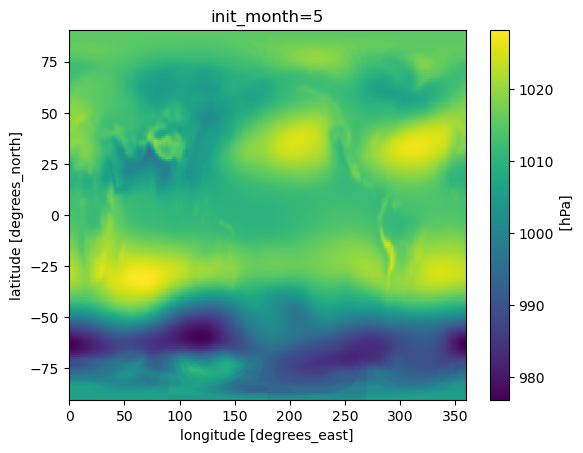

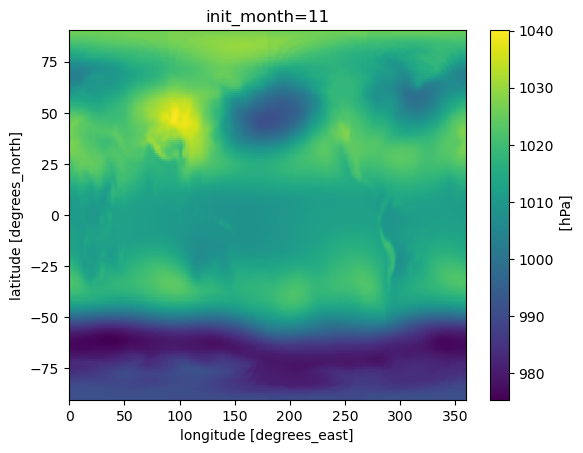

In [51]:
for init_month, da in e3smle_da_by_month.items():
    da.isel(Y=0, L=0, M=0).plot()
    plt.title(f"init_month={init_month}")
    plt.show()

### Get Observational datasets
- Load observational datasets from the E3SM Diags archive (CMOR variables).
- Harmonize in time, variable naming, and space (regridding to a common grid).
- Provide consistent reference fields for hindcast evaluation.
- Compute OBS seasonal averages as a simple rolling mean
- Regrid to analysis grid 

In [52]:
%%time
# Load observations using the selected field configuration.
obs_dir = "/global/cfs/cdirs/e3sm/e3sm_diags/obs_for_e3sm_diags/time-series"
obs_name = cfg["obs_name"]
obs_var = cfg["obs_var"]
obs_map = {field: obs_var}
obs_ys = cfg["obs_ys"]
obs_ye = cfg["obs_ye"]
verbose = True

obs_chunks = {
    "time": 24,
    "lat": 90,
    "lon": 180,
}

obs_monthly = obs_access.get_monthly_data(
    obs_dir=obs_dir,
    field=field,
    field_map=obs_map,
    product=obs_name,
    start_year=obs_ys,
    end_year=obs_ye,
    chunks=obs_chunks,
    verbose=verbose,
)

# Compute OBS seasonal averages.
obs_seas = obs_access.mon_to_seas_obs(
    obs_monthly,
    var=obs_var,
    field_map=obs_map,
)

# Rechunk after rolling.
obs_seas = obs_seas.chunk(obs_chunks)

# Build regridder from Dataset, not DataArray.
regridder_obs = regrid.make_regridder(
    obs_monthly,
    destgrid,
    method=regrid_method,
    periodic=regrid_periodic,
)

# Regrid seasonal DataArray.
try:
    obs_seas_rg = regridder_obs(
        obs_seas,
        output_chunks=obs_chunks,
    )
except TypeError:
    obs_seas_rg = regridder_obs(obs_seas)

# Rechunk after regrid and apply variable-specific unit conversion.
obs_seas_rg = obs_seas_rg.chunk(obs_chunks)
print(obs_seas_rg)

obs_seas_rg = cfg["obs_convert"](obs_seas_rg)
print(obs_seas_rg)

# Backward-compatible aliases for older exploratory cells.
if cfg["obs_name"] == "ERA5":
    obs_era5_seas_rg = obs_seas_rg
if field == "PRECT":
    obs_gpcp_seas_rg = obs_seas_rg


[OBS] Mapping field 'PSL' -> 'psl'
[OBS] Loading: /global/cfs/cdirs/e3sm/diagnostics/observations/Atm/time-series/ERA5/psl_197901_201912.nc
<xarray.DataArray (time: 490, lat: 181, lon: 360)> Size: 128MB
dask.array<astype, shape=(490, 181, 360), dtype=float32, chunksize=(24, 90, 180), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 4kB 1979-02-15 00:00:00 ... 2019-11-15 00:00:00
  * lat      (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 87.0 88.0 89.0 90.0
  * lon      (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
Attributes:
    regrid_method:  conservative
<xarray.DataArray (time: 490, lat: 181, lon: 360)> Size: 128MB
dask.array<mul, shape=(490, 181, 360), dtype=float32, chunksize=(24, 90, 180), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 4kB 1979-02-15 00:00:00 ... 2019-11-15 00:00:00
  * lat      (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 87.0 88.0 89.0 90.0
  * lon      (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.

/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 38.54 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


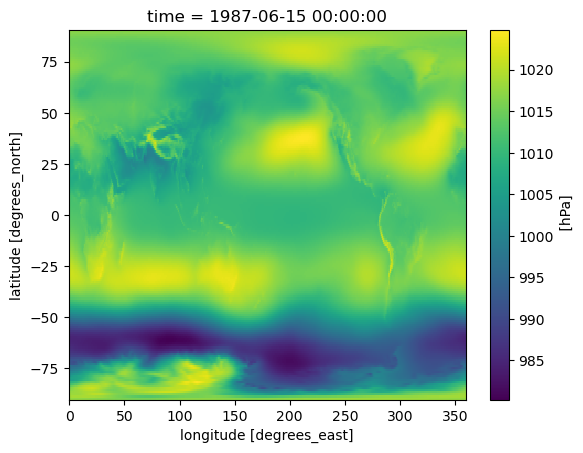

In [53]:
obs_seas_rg.isel(time=100).plot()

# Skill Analysis

In [54]:
%%time
time_by_month = {
    init_month: e3smle_seas_by_month[init_month].time.load()
    for init_month in init_months
}

# Backward-compatible convenience variables for exploratory cells.
e3smle05_time = time_by_month.get(5)
e3smle11_time = time_by_month.get(11)

CPU times: user 39.7 ms, sys: 2.13 ms, total: 41.8 ms
Wall time: 204 ms


In [55]:
%%time
# Compute de-drifted anomalies from specified climatology

anom_by_month = {}
clim_by_month = {}

for init_month in init_months:
    anom_by_month[init_month], clim_by_month[init_month] = stats.remove_drift(
        e3smle_da_by_month[init_month],
        time_by_month[init_month],
        climy0,
        climy1,
    )

# Backward-compatible convenience variables for exploratory cells.
e3smle05_anom = anom_by_month.get(5)
e3smle11_anom = anom_by_month.get(11)
e3smle05_clim = clim_by_month.get(5)
e3smle11_clim = clim_by_month.get(11)

CPU times: user 18.9 ms, sys: 3.62 ms, total: 22.6 ms
Wall time: 22 ms


In [56]:
%%time
# Compute CESM-SMYLE benchmark de-drifted anomalies from the same climatology window.
smyle_time_by_month = {
    init_month: smyle_seas_by_month[init_month].time.load()
    for init_month in init_months
}

smyle_anom_by_month = {}
smyle_clim_by_month = {}

for init_month in init_months:
    smyle_anom_by_month[init_month], smyle_clim_by_month[init_month] = stats.remove_drift(
        smyle_da_by_month[init_month],
        smyle_time_by_month[init_month],
        climy0,
        climy1,
    )

smyle05_time = smyle_time_by_month.get(5)
smyle11_time = smyle_time_by_month.get(11)
smyle05_anom = smyle_anom_by_month.get(5)
smyle11_anom = smyle_anom_by_month.get(11)
smyle05_clim = smyle_clim_by_month.get(5)
smyle11_clim = smyle_clim_by_month.get(11)


CPU times: user 68.2 ms, sys: 6.76 ms, total: 74.9 ms
Wall time: 153 ms


In [57]:
def check_remove_drift(da, da_time, anom, clim, climy0, climy1, name="case"):
    d1 = cftime.DatetimeNoLeap(climy0, 1, 1, 0, 0, 0)
    d2 = cftime.DatetimeNoLeap(climy1, 12, 31, 23, 59, 59)

    masked = da.where((da_time >= d1) & (da_time <= d2))
    clim_manual = masked.mean("M").mean("Y")
    anom_manual = da - clim_manual
    masked_anom = anom.where((da_time >= d1) & (da_time <= d2))

    print(f"=== {name} ===")
    print("raw dims :", da.dims, da.shape)
    print("anom dims:", anom.dims, anom.shape)
    print("clim dims:", clim.dims, clim.shape)

    xr.testing.assert_allclose(clim, clim_manual)
    xr.testing.assert_allclose(anom, anom_manual)
    print("manual reconstruction: PASS")

    resid = masked_anom.mean(("Y", "M"))
    print("max abs masked anomaly mean:", float(abs(resid).max(skipna=True)))

    nvalid = masked.notnull().sum(("Y", "M"))
    print("min valid samples per (L,lat,lon):", int(nvalid.min(skipna=True)))
    print("max valid samples per (L,lat,lon):", int(nvalid.max(skipna=True)))

    print("missing clim cells by lead:")
    print(clim.isnull().sum(("lat", "lon")))

for init_month in init_months:
    check_remove_drift(
        e3smle_da_by_month[init_month],
        time_by_month[init_month],
        anom_by_month[init_month],
        clim_by_month[init_month],
        climy0,
        climy1,
        f"init_month={init_month}",
    )

=== init_month=5 ===
raw dims : ('Y', 'L', 'M', 'lat', 'lon') (39, 8, 10, 181, 360)
anom dims: ('Y', 'L', 'M', 'lat', 'lon') (39, 8, 10, 181, 360)
clim dims: ('L', 'lat', 'lon') (8, 181, 360)
manual reconstruction: PASS
max abs masked anomaly mean: 0.00020365396630950272
min valid samples per (L,lat,lon): 0
max valid samples per (L,lat,lon): 310
missing clim cells by lead:
<xarray.DataArray (L: 8)> Size: 64B
dask.array<sum-aggregate, shape=(8,), dtype=int64, chunksize=(8,), chunktype=numpy.ndarray>
Coordinates:
  * L        (L) int64 64B 3 6 9 12 15 18 21 24
Attributes:
    regrid_method:  conservative
    units:          hPa
=== init_month=11 ===
raw dims : ('Y', 'L', 'M', 'lat', 'lon') (39, 8, 10, 181, 360)
anom dims: ('Y', 'L', 'M', 'lat', 'lon') (39, 8, 10, 181, 360)
clim dims: ('L', 'lat', 'lon') (8, 181, 360)
manual reconstruction: PASS
max abs masked anomaly mean: 0.00019846949726343155
min valid samples per (L,lat,lon): 0
max valid samples per (L,lat,lon): 300
missing clim cell

In [58]:
%%time
# Compute and save skill data separately for each init month
outdir = '/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/E3SMLE'
os.makedirs(outdir, exist_ok=True)

force_compute = False
detrend = False

skill_chunk_model = {
    "Y": -1,
    "L": 8,
    "M": 2,
    "lat": 45,
    "lon": 90,
}

skill_chunk_obs = {
    "time": -1,
    "lat": 45,
    "lon": 90,
}

clim_start = cftime.DatetimeNoLeap(climy0, 1, 1)
clim_end = cftime.DatetimeNoLeap(climy1, 12, 31)

# anom_by_month and time_by_month are keyed by the actual init_month values above.

skill_by_month = {}

obs_skill = obs_seas_rg.chunk(skill_chunk_obs)

for init_month in init_months:
    if detrend:
        outname = f"E3SMLE{init_month:02d}_{field}_skill_clim_{climy0}_{climy1}_detrend.nc"
    else:
        outname = f"E3SMLE{init_month:02d}_{field}_skill_clim_{climy0}_{climy1}.nc"

    outfile = os.path.join(outdir, outname)

    if os.path.exists(outfile) and not force_compute:
        skill_ds = xr.open_dataset(outfile).load()
    else:
        if force_compute and os.path.exists(outfile):
            os.remove(outfile)

        model_anom = anom_by_month[init_month].chunk(skill_chunk_model)
        model_time = time_by_month[init_month]

        skill = stats.compute_skill_seasonal(
            model_anom,
            model_time,
            obs_skill,
            clim_start,
            clim_end,
            1,
            8,
            resamp=0,
            detrend=detrend,
        )

        skill_ds = xr.Dataset({
            "corr": skill.corr,
            "pval": skill.pval,
            "rmse": skill.rmse,
            "msss": skill.msss,
            "rpc": skill.rpc,
            "sig_obs": skill.sig_obs,
            "sig_sig": skill.sig_sig,
            "sig_tot": skill.sig_tot,
            "s2t": skill.s2t,
        }).compute()

        skill_ds.to_netcdf(outfile)

    skill_by_month[init_month] = skill_ds

    print(outfile)
    print(skill_ds)

skill05_ds = skill_by_month.get(5)
skill11_ds = skill_by_month.get(11)

/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 45.28 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.div

/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/E3SMLE/E3SMLE05_PSL_skill_clim_1980_2010.nc
<xarray.Dataset> Size: 23MB
Dimensions:  (lat: 181, lon: 360, L: 8)
Coordinates:
  * lat      (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 87.0 88.0 89.0 90.0
  * lon      (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
  * L        (L) int64 64B 3 6 9 12 15 18 21 24
Data variables:
    corr     (L, lat, lon) float32 2MB 0.2527 0.251 0.2508 ... nan nan nan
    pval     (L, lat, lon) float64 4MB 0.1259 0.1285 0.1288 ... nan nan nan
    rmse     (L, lat, lon) float32 2MB 0.9875 0.9886 0.9887 ... nan nan nan
    msss     (L, lat, lon) float32 2MB 0.02489 0.02265 0.02246 ... nan nan nan
    rpc      (L, lat, lon) float64 4MB 0.6722 0.6696 0.6691 ... nan nan nan
    sig_obs  (L, lat, lon) float32 2MB 3.753 3.753 3.752 ... 4.524 4.525 4.526
    sig_sig  (L, lat, lon) float32 2MB 1.661 1.668 1.668 1.668 ... nan nan nan
    sig_tot  (L, lat, lon) float32 2MB 4.42 4.45 4.45 4.45 ... nan nan nan 

/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 45.30 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.div

/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/E3SMLE/E3SMLE11_PSL_skill_clim_1980_2010.nc
<xarray.Dataset> Size: 23MB
Dimensions:  (lat: 181, lon: 360, L: 8)
Coordinates:
  * lat      (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 87.0 88.0 89.0 90.0
  * lon      (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
  * L        (L) int64 64B 3 6 9 12 15 18 21 24
Data variables:
    corr     (L, lat, lon) float32 2MB 0.2822 0.2825 0.2822 ... nan nan nan
    pval     (L, lat, lon) float64 4MB 0.08178 0.08144 0.08181 ... nan nan nan
    rmse     (L, lat, lon) float32 2MB 1.016 1.015 1.016 1.016 ... nan nan nan
    msss     (L, lat, lon) float32 2MB -0.03282 -0.03117 -0.03154 ... nan nan
    rpc      (L, lat, lon) float64 4MB 0.5571 0.5624 0.5617 ... nan nan nan
    sig_obs  (L, lat, lon) float32 2MB 3.415 3.415 3.415 ... 2.895 2.895 2.896
    sig_sig  (L, lat, lon) float32 2MB 1.973 1.969 1.969 1.969 ... nan nan nan
    sig_tot  (L, lat, lon) float32 2MB 3.896 3.92 3.92 3.92 ... nan n

In [59]:
%%time
# Compute and save CESM-SMYLE benchmark skill with the same observations/settings.
smyle_skill_outdir = SMYLE_BENCHMARK_DIR
os.makedirs(smyle_skill_outdir, exist_ok=True)

smyle_skill_by_month = {}
obs_skill = obs_skill.chunk(skill_chunk_obs)

for init_month in init_months:
    if detrend:
        outname = f"BSMYLE{init_month:02d}_{field}_skill_clim_{climy0}_{climy1}_detrend.nc"
    else:
        outname = f"BSMYLE{init_month:02d}_{field}_skill_clim_{climy0}_{climy1}.nc"

    outfile = os.path.join(smyle_skill_outdir, outname)

    if os.path.exists(outfile) and not force_compute:
        skill_ds = xr.open_dataset(outfile).load()
    else:
        if force_compute and os.path.exists(outfile):
            os.remove(outfile)

        model_anom = smyle_anom_by_month[init_month].chunk(skill_chunk_model)
        model_time = smyle_time_by_month[init_month]

        skill = stats.compute_skill_seasonal(
            model_anom,
            model_time,
            obs_skill,
            clim_start,
            clim_end,
            1,
            8,
            resamp=0,
            detrend=detrend,
        )

        skill_ds = xr.Dataset({
            "corr": skill.corr,
            "pval": skill.pval,
            "rmse": skill.rmse,
            "msss": skill.msss,
            "rpc": skill.rpc,
            "sig_obs": skill.sig_obs,
            "sig_sig": skill.sig_sig,
            "sig_tot": skill.sig_tot,
            "s2t": skill.s2t,
        }).compute()

        skill_ds.to_netcdf(outfile)

    smyle_skill_by_month[init_month] = skill_ds
    print(outfile)
    print(skill_ds)

smyle05_skill_ds = smyle_skill_by_month.get(5)
smyle11_skill_ds = smyle_skill_by_month.get(11)

skill_delta_by_month = {
    init_month: skill_by_month[init_month].corr - smyle_skill_by_month[init_month].corr
    for init_month in init_months
}


/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 45.46 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.div

/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/CESM-SMYLE/BSMYLE05_PSL_skill_clim_1980_2010.nc
<xarray.Dataset> Size: 23MB
Dimensions:  (lat: 181, lon: 360, L: 8)
Coordinates:
  * lat      (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 87.0 88.0 89.0 90.0
  * lon      (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
  * L        (L) int64 64B 3 6 9 12 15 18 21 24
Data variables:
    corr     (L, lat, lon) float32 2MB 0.2891 0.2892 0.2893 ... nan nan nan
    pval     (L, lat, lon) float64 4MB 0.07423 0.07412 0.07408 ... nan nan nan
    rmse     (L, lat, lon) float32 2MB 0.958 0.958 0.958 0.958 ... nan nan nan
    msss     (L, lat, lon) float32 2MB 0.08216 0.08222 0.08224 ... nan nan nan
    rpc      (L, lat, lon) float64 4MB 0.9546 0.9551 0.9552 ... nan nan nan
    sig_obs  (L, lat, lon) float32 2MB 3.753 3.753 3.752 ... 4.524 4.525 4.526
    sig_sig  (L, lat, lon) float32 2MB 1.115 1.115 1.115 1.115 ... nan nan nan
    sig_tot  (L, lat, lon) float32 2MB 3.681 3.682 3.682 3.682 .

/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 45.49 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.div

/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/CESM-SMYLE/BSMYLE11_PSL_skill_clim_1980_2010.nc
<xarray.Dataset> Size: 23MB
Dimensions:  (lat: 181, lon: 360, L: 8)
Coordinates:
  * lat      (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 87.0 88.0 89.0 90.0
  * lon      (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
  * L        (L) int64 64B 3 6 9 12 15 18 21 24
Data variables:
    corr     (L, lat, lon) float32 2MB 0.07984 0.07942 0.07916 ... nan nan nan
    pval     (L, lat, lon) float64 4MB 0.6386 0.6403 0.6414 ... nan nan nan
    rmse     (L, lat, lon) float32 2MB 1.142 1.142 1.142 1.142 ... nan nan nan
    msss     (L, lat, lon) float32 2MB -0.3041 -0.3042 -0.3044 ... nan nan nan
    rpc      (L, lat, lon) float64 4MB 0.1633 0.1625 0.162 ... nan nan nan
    sig_obs  (L, lat, lon) float32 2MB 3.337 3.337 3.337 ... 2.925 2.926 2.926
    sig_sig  (L, lat, lon) float32 2MB 1.893 1.892 1.891 1.891 ... nan nan nan
    sig_tot  (L, lat, lon) float32 2MB 3.871 3.871 3.871 3.871 ..

### Final RMSE Plot: BSMYLE vs E3SMLE
- Reads saved skill files for both BSMYLE/CESM-SMYLE and E3SMLE.
- Plots each initialization month as paired columns: CESM-SMYLE on the left, E3SMLE on the right.
- Adds light latitude-longitude gridlines with labels only on the outer plot edges.


=== Sanity check: data range ===
CESM-SMYLE init_month=5 RMSE min/max: 0.20711278915405273 6.328664779663086
CESM-SMYLE init_month=11 RMSE min/max: 0.2588617503643036 6.89755916595459
E3SMLE init_month=5 RMSE min/max: 0.26154017448425293 6.952043533325195
E3SMLE init_month=11 RMSE min/max: 0.26842501759529114 6.694509029388428
working on figure: fig_psl_rmse_skill_map.png
Saved figure: /global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/fig_psl_rmse_skill_map.png


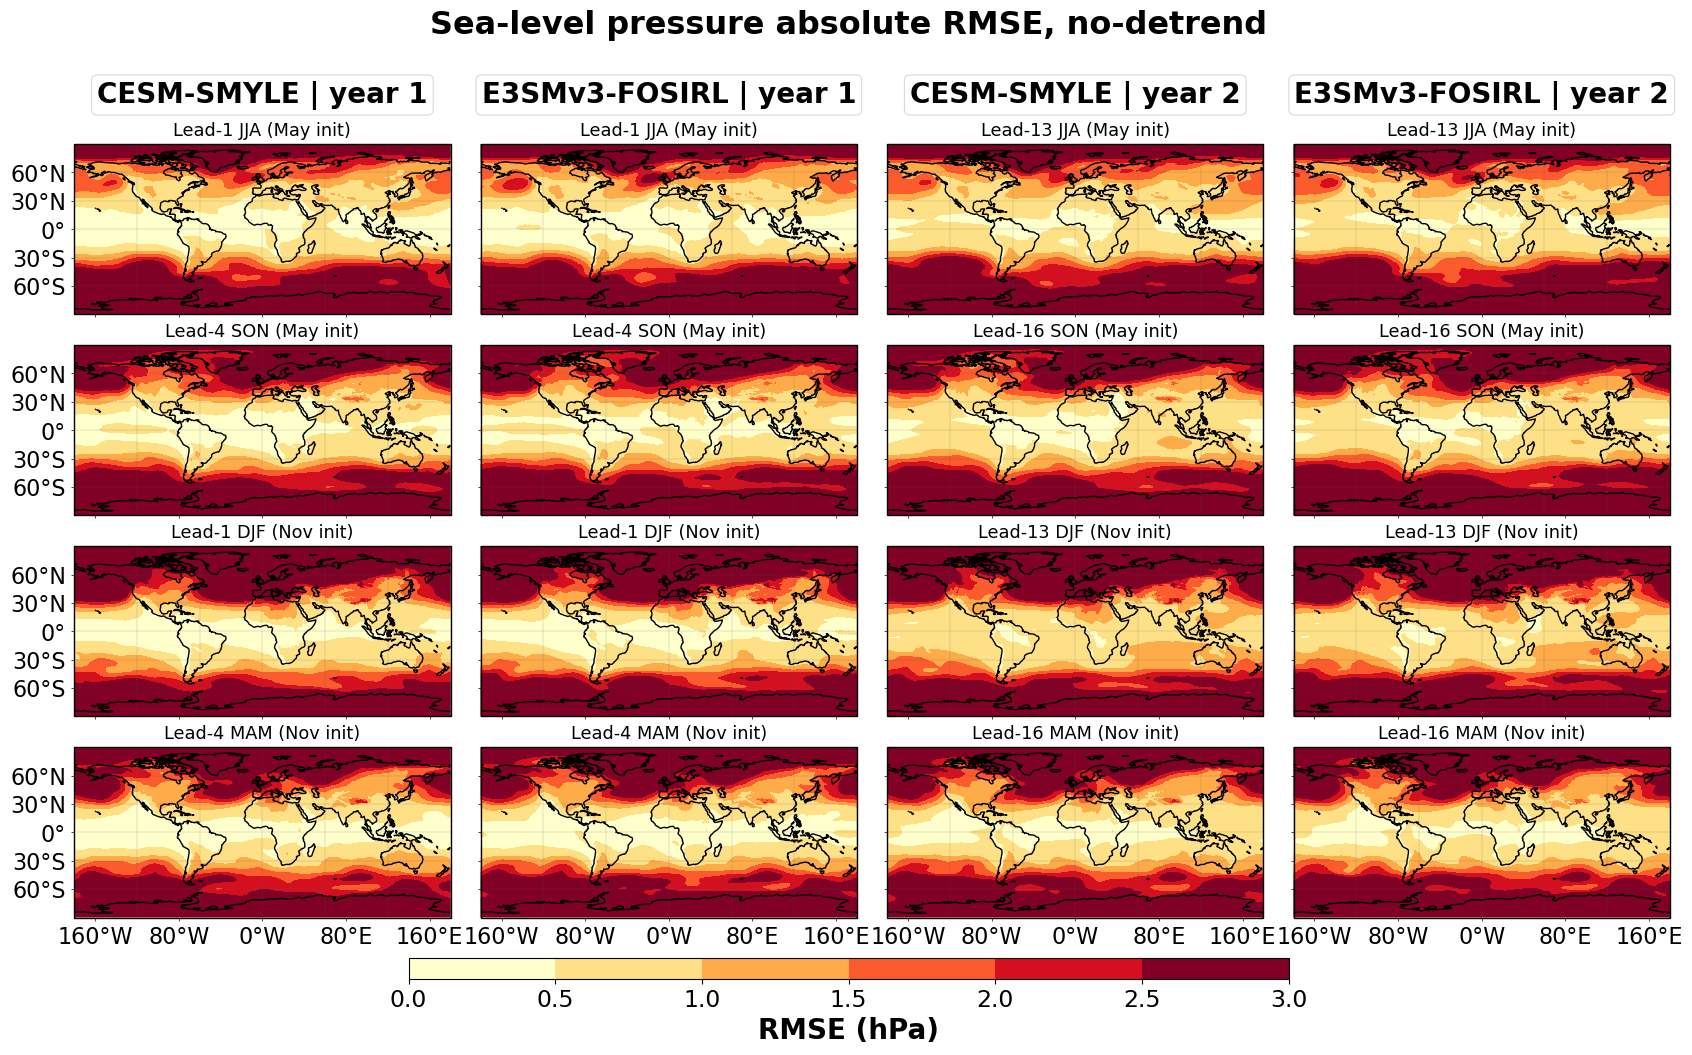

CPU times: user 12 s, sys: 954 ms, total: 12.9 s
Wall time: 12.7 s


In [60]:
%%time
# Read saved BSMYLE/CESM-SMYLE and E3SMv3-FOSIRL skill data and plot side by side.
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter
from matplotlib.offsetbox import AnchoredText
import matplotlib.ticker as mticker

# ---------------------------------------------------------------------------
# User-adjustable final-plot setup
# ---------------------------------------------------------------------------
e3smle_skill_dir = '/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/E3SMLE'
smyle_skill_dir = '/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/CESM-SMYLE'

metric = "RMSE"
metric_units = cfg.get("units", "")
metric_label = f"{metric} ({metric_units})" if metric_units else metric
model_order = ["CESM-SMYLE", "E3SMLE"]
model_display_name = {
    "CESM-SMYLE": "CESM-SMYLE",
    "E3SMLE": "E3SMv3-FOSIRL",
}
# Files retain rolling-window coordinates 3, 6, ..., 24. Figures use the
# original seasonal convention: lead 1 = months 1-3, lead 4 = months 4-6.
season_names = ["DJF", "MAM", "JJA", "SON"]
init_month_names = {
    1: "JAN", 2: "FEB", 3: "MAR", 4: "APR", 5: "MAY", 6: "JUN",
    7: "JUL", 8: "AUG", 9: "SEP", 10: "OCT", 11: "NOV", 12: "DEC",
}

sigon = False
siglvl = 0.1
mask_negacc = False

# Single font-size control for the full multi-panel figure.
fontz = 20
panel_title_size = fontz
lead_label_size = fontz * 0.85
lat_lon_label_size = fontz * 0.8
colorbar_label_size = fontz
colorbar_tick_size = fontz * 0.85
suptitle_size = fontz * 1.15
fweight = 'bold'

# Plot style/layout controls.
figfmt = "png"
fig_col_width = 4.4
fig_row_height = 2.55
projection = ccrs.PlateCarree()
suptitle_y = 0.995
tight_layout_rect = [0.015, 0.13, 0.985, 0.945]
bottom = 0.105
hspace = 0.18
wspace = 0.08

cmap = "YlOrRd"
coff = 0.5
# Use the absolute-RMSE colorbar selected with `field` above.
colorbar_levels = rmse_levels
colorbar_ticks = rmse_ticks
colorbar_tick_decimals = rmse_decimals

colorbar_axes = [0.25, 0.045, 0.5, 0.02]
colorbar_orientation = 'horizontal'
dpi = 300

lon_ticks = [-160, -80, 0, 80, 160]
lat_ticks = [-60, -30, 0, 30, 60]
lat_lon_tick_length = 2.5
lat_lon_tick_width = 0.5
map_axis_linewidth = 1.0
gridline_width = 0.35
gridline_color = "0.35"
gridline_alpha = 0.35
gridline_style = "-"

lead_label_loc = "lower right"
lead_label_pad = 0.25
lead_label_borderpad = 0.35
lead_label_bbox = dict(
    boxstyle="round,pad=0.2",
    facecolor="white",
    edgecolor="lightgray",
    alpha=0.85,
    linewidth=0.8,
)

skill_by_model = {
    "E3SMLE": {},
    "CESM-SMYLE": {},
}

for init_month in init_months:
    if detrend:
        e3smle_name = f"E3SMLE{init_month:02d}_{field}_skill_clim_{climy0}_{climy1}_detrend.nc"
        smyle_name = f"BSMYLE{init_month:02d}_{field}_skill_clim_{climy0}_{climy1}_detrend.nc"
    else:
        e3smle_name = f"E3SMLE{init_month:02d}_{field}_skill_clim_{climy0}_{climy1}.nc"
        smyle_name = f"BSMYLE{init_month:02d}_{field}_skill_clim_{climy0}_{climy1}.nc"

    skill_by_model["E3SMLE"][init_month] = xr.open_dataset(
        os.path.join(e3smle_skill_dir, e3smle_name)
    ).load()
    skill_by_model["CESM-SMYLE"][init_month] = xr.open_dataset(
        os.path.join(smyle_skill_dir, smyle_name)
    ).load()

# Keep the old variable name available for exploratory cells below/above.
skill_by_month = skill_by_model["E3SMLE"]
smyle_skill_by_month = skill_by_model["CESM-SMYLE"]

def seasonal_label(init_month, lead):
    # Native lead is the number of months from initialization through the
    # target season; its center month is therefore init + lead - 1.
    center_month = ((init_month + lead - 2) % 12) + 1
    return season_names[((center_month % 12) // 3)]


def lead_label(init_month, lead):
    display_lead = lead - 2
    init_label = init_month_names.get(init_month, f"{init_month:02d}").title()
    return f"Lead-{display_lead} {seasonal_label(init_month, lead)} ({init_label} init)"


def add_lead_label(ax, text):
    label = AnchoredText(
        text,
        loc=lead_label_loc,
        prop=dict(size=lead_label_size, weight=fweight, family="monospace"),
        frameon=True,
        pad=lead_label_pad,
        borderpad=lead_label_borderpad,
    )
    label.patch.set(**lead_label_bbox)
    ax.add_artist(label)


def set_map_axis_linewidth(ax):
    for spine in ax.spines.values():
        spine.set_linewidth(map_axis_linewidth)
    if hasattr(ax, "outline_patch"):
        ax.outline_patch.set_linewidth(map_axis_linewidth)


def add_lat_lon_labels(ax, row, col, nrows, ncols):
    # Keep labels on the outer edges so the multi-panel plot stays readable.
    set_map_axis_linewidth(ax)
    ax.set_xticks(lon_ticks, crs=projection)
    ax.set_yticks(lat_ticks, crs=projection)
    ax.xaxis.set_major_formatter(LongitudeFormatter(zero_direction_label=True))
    ax.yaxis.set_major_formatter(LatitudeFormatter())
    ax.tick_params(
        labelsize=lat_lon_label_size,
        length=lat_lon_tick_length,
        width=lat_lon_tick_width,
        top=False,
        right=False,
        labelbottom=(row == nrows - 1),
        labelleft=(col == 0),
    )
    ax.gridlines(
        crs=projection,
        linewidth=gridline_width,
        color=gridline_color,
        alpha=gridline_alpha,
        linestyle=gridline_style,
        draw_labels=False,
    )

skill_plot_by_model = skill_by_model

# Organize by verification season so forecast-year growth is not confused
# with the large seasonal cycle in absolute temperature RMSE.
season_comparisons = [
    {"season": "JJA", "init_month": 5, "year_leads": [3, 15]},
    {"season": "SON", "init_month": 5, "year_leads": [6, 18]},
    {"season": "DJF", "init_month": 11, "year_leads": [3, 15]},
    {"season": "MAM", "init_month": 11, "year_leads": [6, 18]},
]
plot_columns = [
    ("CESM-SMYLE", 0), ("E3SMLE", 0),
    ("CESM-SMYLE", 1), ("E3SMLE", 1),
]

for spec in season_comparisons:
    init_month = spec["init_month"]
    for model in model_order:
        if init_month not in skill_plot_by_model[model]:
            raise KeyError(f"Missing {model} skill data for init_month={init_month}.")
        available = np.asarray(skill_plot_by_model[model][init_month].L.values, dtype=int)
        missing = [lead for lead in spec["year_leads"] if lead not in available]
        if missing:
            raise ValueError(
                f"Missing leads {missing} for {model}, init_month={init_month}; "
                f"available={available.tolist()}"
            )

nrows = len(season_comparisons)
ncols = len(plot_columns)

if detrend:
    subtitle = f"{cfg['plot_name']} absolute {metric}, linear-detrend"
    trendstr = "wt_detrend"
else:
    subtitle = f"{cfg['plot_name']} absolute {metric}, no-detrend"
    trendstr = "wo_detrend"

def absolute_rmse(skill_plot):
    if "rmse" not in skill_plot:
        raise KeyError("Absolute RMSE requires 'rmse' in the skill dataset.")
    if "sig_obs" not in skill_plot:
        raise KeyError("Absolute RMSE requires 'sig_obs' to undo RMSE normalization.")

    rmse_abs = skill_plot.rmse * skill_plot.sig_obs
    rmse_abs.attrs["long_name"] = "RMSE"
    rmse_abs.attrs["units"] = metric_units
    return rmse_abs


rmse_by_model = {}
for model in model_order:
    rmse_by_model[model] = {}
    for init_month in sorted({spec["init_month"] for spec in season_comparisons}):
        skill_plot = skill_plot_by_model[model][init_month]
        rmse = absolute_rmse(skill_plot)

        rmse_by_model[model][init_month] = rmse

sigstr = "wo_sigmask"

if colorbar_levels.ndim != 1 or colorbar_levels.size < 2:
    raise ValueError("colorbar_levels must contain at least two values")
level_steps = np.diff(colorbar_levels)
if np.any(level_steps <= 0) or not np.allclose(level_steps, level_steps[0]):
    raise ValueError("colorbar_levels must be strictly increasing and uniformly spaced")
cmin = float(colorbar_levels[0])
cmax = float(colorbar_levels[-1])
ci = float(level_steps[0])

print("=== Sanity check: data range ===")
for model in model_order:
    for init_month, rmse in rmse_by_model[model].items():
        print(
            f"{model} init_month={init_month} RMSE min/max:",
            float(rmse.min(skipna=True)),
            float(rmse.max(skipna=True)),
        )

figname = figure_filename(field, "rmse_skill_map", ext=figfmt)

print(f"working on figure: {figname}")

fig = plt.figure(figsize=(fig_col_width * ncols, fig_row_height * nrows))
fig.suptitle(subtitle, fontsize=suptitle_size, fontweight=fweight, y=suptitle_y)
proj = projection
cntr = None
top_row_axes = {}

for i, spec in enumerate(season_comparisons):
    season = spec["season"]
    init_month = spec["init_month"]
    init_label = init_month_names.get(init_month, f"{init_month:02d}")

    for j, (model, year_index) in enumerate(plot_columns):
        lead = spec["year_leads"][year_index]
        forecast_year = year_index + 1
        skill_plot = skill_plot_by_model[model][init_month]
        subplot = i * ncols + j + 1
        model_name = model_display_name.get(model, model)
        title = lead_label(init_month, lead)

        ax, cntr = maps.map_pcolor_global_subplot(
            fig,
            rmse_by_model[model][init_month].sel(L=lead),
            skill_plot.lon,
            skill_plot.lat,
            ci, cmin, cmax,
            title,
            nrows, ncols, subplot,
            proj, cmap=cmap, cutoff=coff,
            fontsize=lead_label_size * 0.75,
        )
        if i == 0:
            top_row_axes[j] = ax
        add_lat_lon_labels(ax, i, j, nrows, ncols)

fig.tight_layout(rect=tight_layout_rect, h_pad=0.65, w_pad=0.35)
fig.subplots_adjust(bottom=bottom, hspace=hspace, wspace=wspace)
fig.canvas.draw()
renderer = fig.canvas.get_renderer()
title_tops = [
    ax.title.get_window_extent(renderer=renderer)
    .transformed(fig.transFigure.inverted()).y1
    for ax in top_row_axes.values()
]
column_header_y = min(0.952, max(title_tops) + 0.012)
for j, (model, year_index) in enumerate(plot_columns):
    model_name = model_display_name.get(model, model)
    fig.text(
        0.5 * (top_row_axes[j].get_position().x0 + top_row_axes[j].get_position().x1),
        column_header_y,
        f"{model_name} | year {year_index + 1}",
        ha="center",
        va="bottom",
        fontsize=panel_title_size,
        fontweight=fweight,
        bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="lightgray", alpha=0.85, linewidth=0.8),
    )
cbar_ax = fig.add_axes(colorbar_axes)
cbar = fig.colorbar(cntr, cax=cbar_ax, orientation=colorbar_orientation)
cbar.set_ticks(colorbar_ticks)
tick_format = f"%.{colorbar_tick_decimals}f"
cbar.ax.xaxis.set_major_formatter(mticker.FormatStrFormatter(tick_format))
cbar.set_label(metric_label, fontsize=colorbar_label_size, fontweight=fweight)
cbar.ax.tick_params(labelsize=colorbar_tick_size)

figpath = FIGURE_OUTDIR / figname
mov.save_figure(
    fig, figpath,
    mode="",
    metric="leadtime_rmse",
    title=f"Leadtime RMSE: {field}",
    caption="RMSE skill vs lead month, global",
    dpi=dpi,
)
print("Saved figure:", figpath)
plt.show()


=== CONUS lead selection ===
Saved figure: /global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/fig_psl_rmse_skill_conus.png


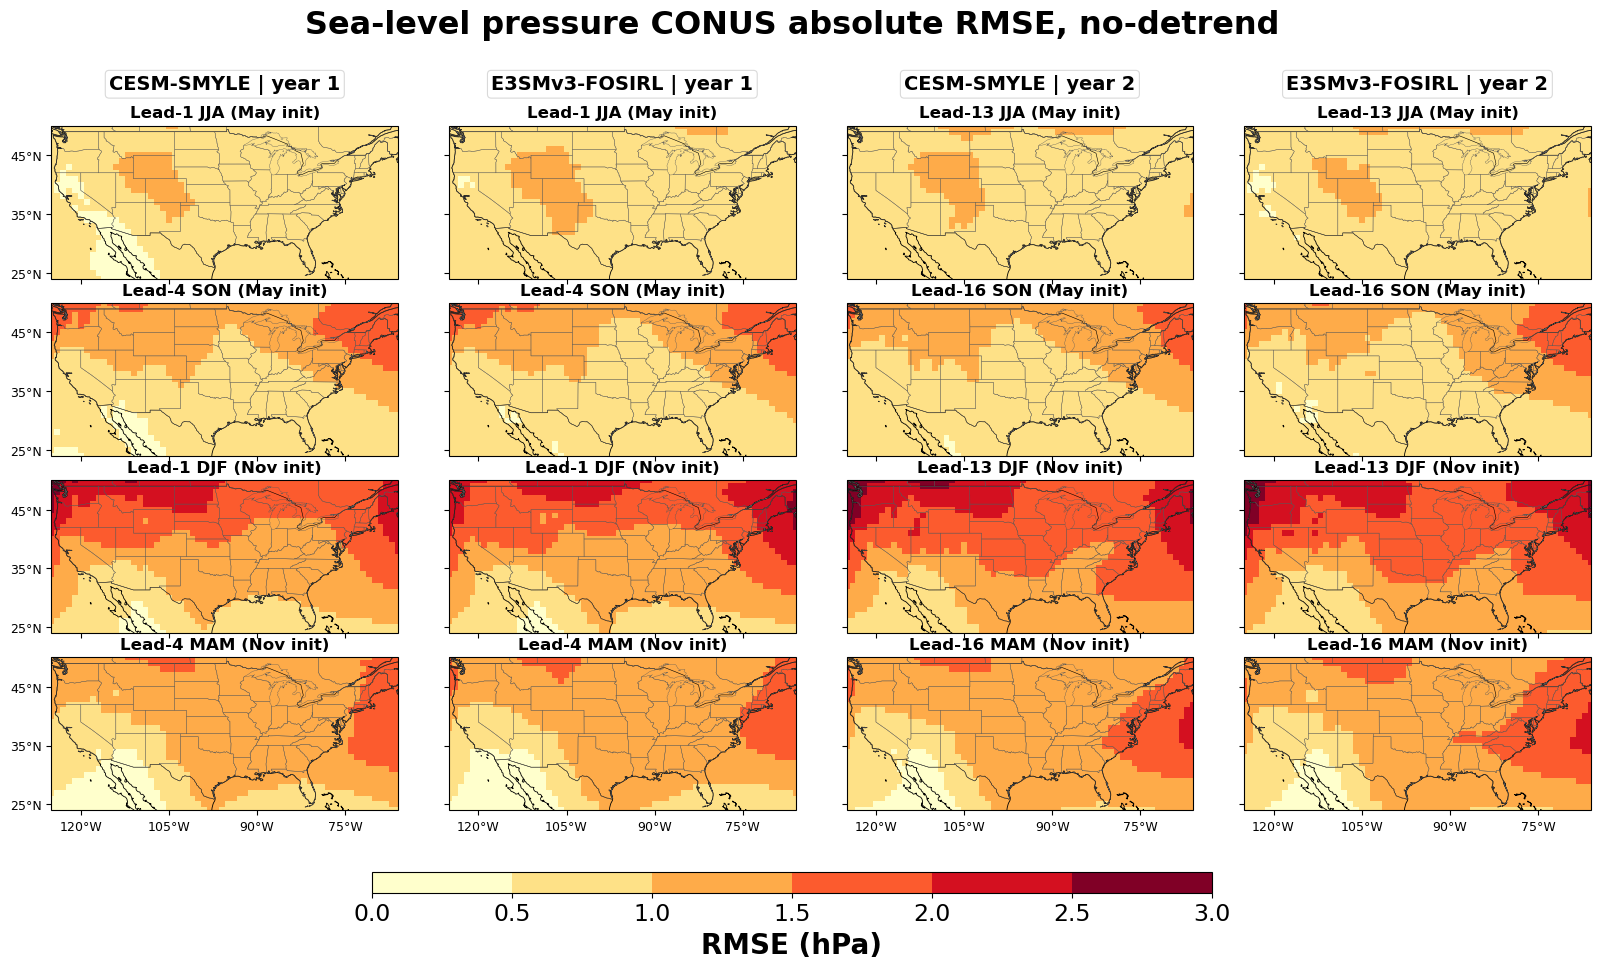

CPU times: user 3.93 s, sys: 356 ms, total: 4.28 s
Wall time: 4.09 s


In [61]:
%%time
# CONUS absolute RMSE growth for the same verification seasons.
# Run after the global absolute-RMSE plotting cell above so skill_plot_by_model
# and absolute_rmse are already defined.
import cartopy.feature as cfeature
from matplotlib.colors import BoundaryNorm
conus_models = ["CESM-SMYLE", "E3SMLE"]
conus_detrend = False  # absolute RMSE should usually show non-detrended model error
# Rows are verification seasons; columns compare both models in years 1 and 2.
conus_seasons = [
    ("JJA", 5, [3, 15]),
    ("SON", 5, [6, 18]),
    ("DJF", 11, [3, 15]),
    ("MAM", 11, [6, 18]),
]
conus_extent = [-125, -66, 24, 50]
conus_cmap = "YlOrRd"
# Use the absolute-RMSE colorbar selected with `field` above.
conus_colorbar_levels = rmse_levels
conus_colorbar_ticks = rmse_ticks
conus_colorbar_tick_decimals = rmse_decimals
conus_col_width = 4.2
conus_row_height = 2.35
conus_panel_title_size = 12
conus_column_header_size = 14
conus_tick_size = 9
conus_hspace = 0.16
conus_wspace = 0.04

# Defaults needed if this cell is run without the global RMSE map cell above.
e3smle_skill_dir = globals().get("e3smle_skill_dir", "/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/E3SMLE")
smyle_skill_dir = globals().get("smyle_skill_dir", "/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/CESM-SMYLE")
metric = globals().get("metric", "RMSE")
metric_units = globals().get("metric_units", cfg.get("units", ""))
metric_label = globals().get("metric_label", f"{metric} ({metric_units})" if metric_units else metric)
figfmt = globals().get("figfmt", "png")
dpi = globals().get("dpi", 300)
bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="lightgray", alpha=0.85, linewidth=0.8),
fweight = globals().get("fweight", "bold")
suptitle_size = globals().get("suptitle_size", 22)
colorbar_label_size = globals().get("colorbar_label_size", 18)
colorbar_tick_size = globals().get("colorbar_tick_size", 15)


def require_available_lead(da, target_lead):
    available = np.asarray(da.L.values, dtype=int)
    if target_lead not in available:
        raise ValueError(
            f"Requested lead {target_lead} is unavailable; native leads are {available.tolist()}."
        )
    return int(target_lead)


def subset_conus(da):
    if float(da.lon.max()) > 180:
        da = da.sel(lon=slice(235, 294))
        da = da.assign_coords(lon=(((da.lon + 180) % 360) - 180))
        da = da.sortby("lon")
    else:
        da = da.sel(lon=slice(conus_extent[0], conus_extent[1]))

    lat_slice = slice(conus_extent[2], conus_extent[3])
    if da.lat.size > 1 and float(da.lat[0]) > float(da.lat[-1]):
        lat_slice = slice(conus_extent[3], conus_extent[2])
    return da.sel(lat=lat_slice)


def add_conus_features(ax):
    for feature, kwargs in [
        (cfeature.COASTLINE, {"linewidth": 0.6}),
        (cfeature.BORDERS, {"linewidth": 0.4}),
        (cfeature.STATES, {"linewidth": 0.25, "edgecolor": "0.35"}),
    ]:
        try:
            ax.add_feature(feature, **kwargs)
        except Exception as err:
            print(f"Skipping Cartopy feature {feature}: {err}")


def absolute_rmse_from_skill(skill_plot):
    if "rmse" not in skill_plot:
        raise KeyError("Absolute RMSE requires 'rmse' in the skill dataset.")
    if "sig_obs" not in skill_plot:
        raise KeyError("Absolute RMSE requires 'sig_obs' to undo RMSE normalization.")

    rmse_abs = skill_plot.rmse * skill_plot.sig_obs
    rmse_abs.attrs["long_name"] = "RMSE"
    rmse_abs.attrs["units"] = metric_units
    return rmse_abs


if "absolute_rmse" not in globals():
    absolute_rmse = absolute_rmse_from_skill

if "skill_plot_by_model" not in globals():
    print("skill_plot_by_model not found; loading saved skill datasets for CONUS plot.")
    skill_by_model = {"E3SMLE": {}, "CESM-SMYLE": {}}
    for init_month in init_months:
        if conus_detrend:
            e3smle_name = f"E3SMLE{init_month:02d}_{field}_skill_clim_{climy0}_{climy1}_detrend.nc"
            smyle_name = f"BSMYLE{init_month:02d}_{field}_skill_clim_{climy0}_{climy1}_detrend.nc"
        else:
            e3smle_name = f"E3SMLE{init_month:02d}_{field}_skill_clim_{climy0}_{climy1}.nc"
            smyle_name = f"BSMYLE{init_month:02d}_{field}_skill_clim_{climy0}_{climy1}.nc"

        e3smle_path = os.path.join(e3smle_skill_dir, e3smle_name)
        smyle_path = os.path.join(smyle_skill_dir, smyle_name)
        missing_paths = [path for path in [e3smle_path, smyle_path] if not os.path.exists(path)]
        if missing_paths:
            missing = "\n".join(missing_paths)
            raise FileNotFoundError(
                "Missing non-detrended RMSE skill file(s) for the CONUS plot.\n"
                "For absolute RMSE, run the skill-computation cell with detrend = False first, "
                "or set conus_detrend = True if you intentionally want the existing detrended cache.\n"
                f"Missing:\n{missing}"
            )

        skill_by_model["E3SMLE"][init_month] = xr.open_dataset(
            e3smle_path
        ).load()
        skill_by_model["CESM-SMYLE"][init_month] = xr.open_dataset(
            smyle_path
        ).load()

    skill_plot_by_model = skill_by_model


conus_fields = {model: {} for model in conus_models}
conus_actual_leads = {model: {} for model in conus_models}
for model in conus_models:
    for season_name, init_month, season_leads in conus_seasons:
        if init_month not in skill_plot_by_model[model]:
            raise KeyError(f"Missing {model} skill data for init_month={init_month}.")
        rmse_abs = absolute_rmse(skill_plot_by_model[model][init_month])
        conus_fields[model][season_name] = {}
        conus_actual_leads[model][season_name] = {}
        for target_lead in season_leads:
            actual_lead = require_available_lead(rmse_abs, target_lead)
            conus_actual_leads[model][season_name][target_lead] = actual_lead
            conus_fields[model][season_name][target_lead] = subset_conus(
                rmse_abs.sel(L=actual_lead)
            )

if conus_colorbar_levels.ndim != 1 or conus_colorbar_levels.size < 2:
    raise ValueError("conus_colorbar_levels must contain at least two values")
conus_level_steps = np.diff(conus_colorbar_levels)
if np.any(conus_level_steps <= 0):
    raise ValueError("conus_colorbar_levels must be strictly increasing")
conus_cmap_obj = plt.get_cmap(conus_cmap)
conus_norm = BoundaryNorm(conus_colorbar_levels, conus_cmap_obj.N, clip=True)

print("=== CONUS lead selection ===")
for model in conus_models:
    for season_name in conus_fields[model]:
        for target_lead, actual_lead in conus_actual_leads[model][season_name].items():
            if actual_lead != target_lead:
                print(
                    f"{model} {season_name}: requested lead {target_lead}, "
                    f"using available seasonal lead {actual_lead}"
                )

conus_plot_columns = [
    ("CESM-SMYLE", 0), ("E3SMLE", 0),
    ("CESM-SMYLE", 1), ("E3SMLE", 1),
]
nrows = len(conus_seasons)
ncols = len(conus_plot_columns)
conus_figsize = (conus_col_width * ncols, conus_row_height * nrows)
fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=conus_figsize,
    subplot_kw={"projection": ccrs.PlateCarree()},
    squeeze=False,
)

cntr = None
top_row_axes = {}
for i, (season_name, init_month, season_leads) in enumerate(conus_seasons):
    for j, (model, year_index) in enumerate(conus_plot_columns):
        target_lead = season_leads[year_index]
        ax = axes[i, j]
        da = conus_fields[model][season_name][target_lead]
        actual_lead = conus_actual_leads[model][season_name][target_lead]
        cntr = ax.pcolormesh(
            da.lon,
            da.lat,
            da,
            shading="nearest",
            cmap=conus_cmap_obj,
            norm=conus_norm,
            rasterized=True,
            transform=ccrs.PlateCarree(),
        )
        ax.set_extent(conus_extent, crs=ccrs.PlateCarree())
        add_conus_features(ax)
        panel_title = lead_label(init_month, actual_lead)
        ax.set_title(panel_title, fontsize=conus_panel_title_size, fontweight=fweight)
        if i == 0:
            top_row_axes[j] = ax
        ax.set_xticks([-120, -105, -90, -75], crs=ccrs.PlateCarree())
        ax.set_yticks([25, 35, 45], crs=ccrs.PlateCarree())
        ax.xaxis.set_major_formatter(LongitudeFormatter(zero_direction_label=True))
        ax.yaxis.set_major_formatter(LatitudeFormatter())
        ax.tick_params(
            labelsize=conus_tick_size,
            labelbottom=(i == nrows - 1),
            labelleft=(j == 0),
            top=False,
            right=False,
        )

conus_trend_label = "linear-detrend" if conus_detrend else "no-detrend"
fig.suptitle(
    f"{cfg['plot_name']} CONUS absolute RMSE, {conus_trend_label}",
    fontsize=suptitle_size,
    fontweight=fweight,
    y=0.995,
)
fig.tight_layout(rect=[0.015, 0.12, 0.995, 0.94], h_pad=0.65, w_pad=0.45)
fig.subplots_adjust(hspace=conus_hspace, wspace=conus_wspace)
fig.canvas.draw()
renderer = fig.canvas.get_renderer()
title_tops = [
    ax.title.get_window_extent(renderer=renderer)
    .transformed(fig.transFigure.inverted()).y1
    for ax in top_row_axes.values()
]
column_header_y = min(0.96, max(title_tops) + 0.012)
for j, (model, year_index) in enumerate(conus_plot_columns):
    model_name = globals().get("model_display_name", {}).get(model, model)
    fig.text(
        0.5 * (top_row_axes[j].get_position().x0 + top_row_axes[j].get_position().x1),
        column_header_y,
        f"{model_name} | year {year_index + 1}",
        ha="center",
        va="bottom",
        fontsize=conus_column_header_size,
        fontweight=fweight,
        bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="lightgray", alpha=0.85, linewidth=0.8),
    )
cbar_ax = fig.add_axes([0.25, 0.055, 0.5, 0.022])
cbar = fig.colorbar(cntr, cax=cbar_ax, orientation="horizontal")
cbar.set_ticks(conus_colorbar_ticks)
conus_tick_format = f"%.{conus_colorbar_tick_decimals}f"
cbar.ax.xaxis.set_major_formatter(mticker.FormatStrFormatter(conus_tick_format))
cbar.set_label(metric_label, fontsize=colorbar_label_size, fontweight=fweight)
cbar.ax.tick_params(labelsize=colorbar_tick_size)

conus_figname = figure_filename(field, "rmse_skill_conus", ext=figfmt)
conus_figpath = FIGURE_OUTDIR / conus_figname
mov.save_figure(
    fig, conus_figpath,
    mode="",
    metric="leadtime_rmse_conus",
    title=f"Leadtime RMSE CONUS: {field}",
    caption="RMSE skill CONUS, all seasons",
    dpi=dpi,
)
print("Saved figure:", conus_figpath)
plt.show()

In [62]:
%%time
# CESM-SMYLE vs E3SMLE normalized-RMSE ensemble comparison.
#
# Scientific purpose:
# 1. Restrict CESM-SMYLE and E3SMLE to common verification years.
# 2. Resample the larger CESM-SMYLE ensemble to the E3SMLE ensemble size.
# 3. Repeat the CESM-SMYLE subsampling N times without replacement.
# 4. Compute P(E3SMLE nRMSE < matched-size CESM-SMYLE nRMSE).
# 5. Store two-sided resampling values and left/right robustness masks using
#    compare_alpha, matching the finite-ensemble output convention in 3_ref*.
#
# Dask strategy:
# - Use Dask for the expensive skill calculations.
# - Cache comparison anomalies to NetCDF once and reopen them with chunks.
# - Avoid persist() by default to reduce memory pressure and large Dask graphs.

import importlib
stats = importlib.reload(stats)

compare_mode = "final"   # "test" or "final"

compare_force_recompute = False
compare_detrend = True
compare_random_seed = 42
compare_alpha = 0.1  # 90% finite-ensemble robustness threshold

# Recommended for production:
# True  -> write comparison anomalies once and reopen as Dask-backed arrays.
# False -> directly use upstream lazy anomaly arrays.
cache_compare_anomalies = True

# Usually keep False. Persisting full anomaly arrays can increase memory pressure.
persist_compare_inputs = False


if compare_mode == "test":
    compare_init_months = [11]
    compare_iterations = 10
    compare_lead_start = 1
    compare_lead_end = 8

elif compare_mode == "final":
    compare_init_months = [5, 11]
    compare_iterations = 100
    compare_lead_start = 1
    compare_lead_end = 8

else:
    raise ValueError("compare_mode must be 'test' or 'final'")


# Dedicated chunks keep each lead and spatial tile manageable.
compare_chunk_model = {
    "Y": -1,
    "M": -1,
    "L": 1,
    "lat": 30,
    "lon": 60,
}
compare_chunk_obs = {
    "time": -1,
    "lat": 30,
    "lon": 60,
}
# Moderate checkpoints reduce repeated source reads while limiting worker
# memory. Completed batches are reused after an interruption or restart.
compare_iteration_batch_size = 25


obs_compare = obs_seas_rg.chunk(compare_chunk_obs)

compare_cache_dir_e3sm = (
    e3smle_skill_dir
    if "e3smle_skill_dir" in globals()
    else "/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/E3SMLE"
)

compare_cache_dir_smyle = (
    smyle_skill_dir
    if "smyle_skill_dir" in globals()
    else "/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/CESM-SMYLE"
)

os.makedirs(compare_cache_dir_e3sm, exist_ok=True)
os.makedirs(compare_cache_dir_smyle, exist_ok=True)


def _safe_to_netcdf(ds, path):
    """
    Safely write a Dataset to NetCDF using a temporary file first.
    This avoids corrupted cache files if the job is interrupted.
    """
    tmp_path = path + ".tmp"

    if os.path.exists(tmp_path):
        os.remove(tmp_path)

    ds.to_netcdf(tmp_path)
    os.replace(tmp_path, path)


def _open_dataset_load(path):
    """
    Open a small cached result and load it into memory.
    Used for final skill / p-value outputs, not large anomaly inputs.
    """
    with xr.open_dataset(path) as ds:
        return ds.load()


def _cache_compare_anomaly(
    da,
    path,
    varname="anom",
    chunks=None,
    force=False,
):
    """
    Save a comparison anomaly DataArray once and reopen it with Dask chunks.

    This reduces the Dask graph size because the expensive significance
    calculation starts from NetCDF reads rather than from the full upstream
    lazy-processing graph.
    """
    if force or not os.path.exists(path):
        print(f"Writing cached anomaly: {path}")
        _safe_to_netcdf(da.to_dataset(name=varname), path)

    print(f"Opening cached anomaly with Dask chunks: {path}")
    return xr.open_dataset(path, chunks=chunks)[varname]


def _compare_cache_paths(init_month, ens_size, years):
    base = f"{field}_clim_{climy0}_{climy1}"
    trend = "detrend" if compare_detrend else "nodetrend"
    year_token = f"{str(years[0])[:4]}-{str(years[-1])[:4]}_ny{len(years)}"
    mode = f"{compare_mode}_n{ens_size}_iter{compare_iterations}_seed{compare_random_seed}_{year_token}"

    smyle_file = os.path.join(
        compare_cache_dir_smyle,
        f"BSMYLE{init_month:02d}_{base}_resamp_to_e3sm_rmse_{trend}_{mode}.nc",
    )

    e3sm_file = os.path.join(
        compare_cache_dir_e3sm,
        f"E3SMLE{init_month:02d}_{base}_fixed_rmse_{trend}_{year_token}.nc",
    )

    fraction_file = os.path.join(
        compare_cache_dir_e3sm,
        f"BSMYLE_lt_E3SMLE{init_month:02d}_{base}_rmse_fraction_{trend}_{mode}.nc",
    )

    return smyle_file, e3sm_file, fraction_file


def _compare_anomaly_cache_paths(init_month, years):
    base = f"{field}_clim_{climy0}_{climy1}"
    trend = "detrend" if compare_detrend else "nodetrend"

    year_token = f"{str(years[0])[:4]}-{str(years[-1])[:4]}_ny{len(years)}"

    smyle_anom_file = os.path.join(
        compare_cache_dir_smyle,
        f"BSMYLE{init_month:02d}_{base}_compare_anom_{trend}_{year_token}.nc",
    )

    e3sm_anom_file = os.path.join(
        compare_cache_dir_e3sm,
        f"E3SMLE{init_month:02d}_{base}_compare_anom_{trend}_{year_token}.nc",
    )

    return smyle_anom_file, e3sm_anom_file


def _compare_prepared_cache_paths(smyle_file, lead):
    stem, suffix = os.path.splitext(smyle_file)
    return (
        f"{stem}_prepared_model_L{int(lead):02d}{suffix}",
        f"{stem}_prepared_obs_L{int(lead):02d}{suffix}",
    )


def _compare_lead_cache_path(smyle_file, lead):
    stem, suffix = os.path.splitext(smyle_file)
    return f"{stem}_L{int(lead):02d}_all_iterations{suffix}"


def _compare_batch_cache_path(smyle_file, lead, batch_start, batch_stop):
    stem, suffix = os.path.splitext(smyle_file)
    return (
        f"{stem}_L{int(lead):02d}_batch_"
        f"{batch_start:03d}_{batch_stop:03d}{suffix}"
    )


def _build_rmse_significance_dataset(
    smyle_better_fraction,
    alpha,
    prob_left_lower=None,
    n_iterations=None,
    matched_ensemble_size=None,
    smyle_ensemble_size=None,
):
    """Build the same finite-ensemble significance fields used in 3_ref*."""
    if prob_left_lower is None:
        # Compatibility fallback for caches created before this dataset existed.
        prob_left_lower = (1.0 - smyle_better_fraction).clip(0.0, 1.0)
    p_two = xr.where(
        prob_left_lower <= 0.5,
        2.0 * prob_left_lower,
        2.0 * (1.0 - prob_left_lower),
    ).clip(0.0, 1.0)

    ds = xr.Dataset(
        {
            "prob_left_lower_rmse": prob_left_lower.astype("float32"),
            "p_two_sided_resampling": p_two.astype("float32"),
            "left_better": (prob_left_lower >= 1.0 - alpha).astype("int8"),
            "right_better": (prob_left_lower <= alpha).astype("int8"),
            # Retain the original field for backward compatibility.
            "smyle_better_fraction": smyle_better_fraction.astype("float32"),
        }
    )
    ds.attrs.update(
        alpha=float(alpha),
        left_model="E3SMLE",
        right_model="CESM-SMYLE",
        resampling_method=(
            "Fixed smaller E3SMLE ensemble; CESM-SMYLE sampled without "
            "replacement to matched size; verification years held fixed"
        ),
        interpretation="Finite-ensemble robustness, not a bootstrap over years",
    )
    if n_iterations is not None:
        ds.attrs["n_iterations"] = int(n_iterations)
    if matched_ensemble_size is not None:
        ds.attrs["matched_ensemble_size"] = int(matched_ensemble_size)
    if smyle_ensemble_size is not None:
        ds.attrs["smyle_ensemble_size"] = int(smyle_ensemble_size)
    return ds


rng = np.random.default_rng(compare_random_seed)

smyle_compare_skill_by_month = {}
e3sm_compare_skill_by_month = {}
smyle_better_fraction_by_month = {}
rmse_significance_by_month = {}
compare_years_by_month = {}
compare_ens_size_by_month = {}


for compare_init_month in compare_init_months:
    e3sm_compare_member_count = anom_by_month[compare_init_month].sizes["M"]
    smyle_compare_member_count = smyle_anom_by_month[compare_init_month].sizes["M"]

    if smyle_compare_member_count < e3sm_compare_member_count:
        raise ValueError(
            "This comparison expects CESM-SMYLE to be the larger ensemble; "
            f"got SMYLE={smyle_compare_member_count}, E3SMLE={e3sm_compare_member_count}."
        )
    compare_ens_size = e3sm_compare_member_count
    compare_ens_size_by_month[compare_init_month] = compare_ens_size

    compare_years = np.intersect1d(
        smyle_anom_by_month[compare_init_month].Y.values,
        anom_by_month[compare_init_month].Y.values,
    )
    compare_years_by_month[compare_init_month] = compare_years

    smyle_file, e3sm_file, fraction_file = _compare_cache_paths(
        compare_init_month, compare_ens_size, compare_years
    )

    if (
        not compare_force_recompute
        and os.path.exists(smyle_file)
        and os.path.exists(e3sm_file)
        and os.path.exists(fraction_file)
    ):
        print(f"Loading cached significance results for init_month={compare_init_month}")

        smyle_skill_tmp = _open_dataset_load(smyle_file)
        e3sm_skill_tmp = _open_dataset_load(e3sm_file)

        with xr.open_dataset(fraction_file) as ds:
            required_significance_vars = {
                "prob_left_lower_rmse",
                "p_two_sided_resampling",
                "left_better",
                "right_better",
            }
            cache_needs_upgrade = (
                not required_significance_vars.issubset(ds.data_vars)
                or float(ds.attrs.get("alpha", -1.0)) != float(compare_alpha)
            )
            if "smyle_better_fraction" in ds:
                smyle_better_fraction_tmp = ds["smyle_better_fraction"].load()
            else:
                smyle_better_fraction_tmp = (
                    1.0 - ds["prob_left_lower_rmse"]
                ).load()
            prob_left_lower_tmp = (
                ds["prob_left_lower_rmse"].load()
                if "prob_left_lower_rmse" in ds else None
            )
        rmse_significance_tmp = _build_rmse_significance_dataset(
            smyle_better_fraction_tmp,
            compare_alpha,
            prob_left_lower=prob_left_lower_tmp,
            n_iterations=compare_iterations,
            matched_ensemble_size=compare_ens_size,
            smyle_ensemble_size=smyle_compare_member_count,
        )
        if cache_needs_upgrade:
            print("Upgrading finite-ensemble significance cache:", fraction_file)
            _safe_to_netcdf(rmse_significance_tmp, fraction_file)

    else:
        print(f"Computing significance results for init_month={compare_init_month}")
        print(f"compare_mode       : {compare_mode}")
        print(f"compare_iterations : {compare_iterations}")
        print(f"compare_alpha      : {compare_alpha}")
        print(f"compare_leads      : {compare_lead_start} to {compare_lead_end}")
        print(f"compare_detrend    : {compare_detrend}")
        print(f"cache anomalies    : {cache_compare_anomalies}")
        print(f"persist inputs     : {persist_compare_inputs}")

        smyle_compare_anom = (
            smyle_anom_by_month[compare_init_month]
            .sel(Y=compare_years)
            .chunk(compare_chunk_model)
        )

        e3sm_compare_anom = (
            anom_by_month[compare_init_month]
            .sel(Y=compare_years)
            .chunk(compare_chunk_model)
        )

        if cache_compare_anomalies:
            smyle_anom_file, e3sm_anom_file = _compare_anomaly_cache_paths(
                compare_init_month, compare_years
            )

            smyle_compare_anom = _cache_compare_anomaly(
                smyle_compare_anom,
                smyle_anom_file,
                varname="anom",
                chunks=compare_chunk_model,
                force=compare_force_recompute,
            )

            e3sm_compare_anom = _cache_compare_anomaly(
                e3sm_compare_anom,
                e3sm_anom_file,
                varname="anom",
                chunks=compare_chunk_model,
                force=compare_force_recompute,
            )

        elif persist_compare_inputs:
            smyle_compare_anom = smyle_compare_anom.persist()
            e3sm_compare_anom = e3sm_compare_anom.persist()
            wait([smyle_compare_anom, e3sm_compare_anom])

        smyle_compare_time = smyle_time_by_month[compare_init_month].sel(
            Y=compare_years
        )

        e3sm_compare_time = time_by_month[compare_init_month].sel(
            Y=compare_years
        )

        if os.path.exists(e3sm_file) and not compare_force_recompute:
            print("Loading cached fixed E3SMLE comparison RMSE...")
            e3sm_skill_tmp = _open_dataset_load(e3sm_file)
        else:
            print("Computing fixed E3SMLE comparison RMSE...")
            e3sm_skill_tmp = stats.compute_skill_seasonal(
                e3sm_compare_anom,
                e3sm_compare_time,
                obs_compare,
                str(climy0),
                str(climy1),
                compare_lead_start,
                compare_lead_end,
                resamp=0,
                detrend=compare_detrend,
            )[["rmse"]].load()
            _safe_to_netcdf(e3sm_skill_tmp, e3sm_file)

        print("Computing CESM-SMYLE matched-ensemble RMSE distribution...")

        member_indices_all = np.stack([
            rng.choice(
                smyle_compare_member_count,
                size=compare_ens_size,
                replace=False,
            )
            for _ in range(compare_iterations)
        ])

        smyle_skill_leads = []
        lead_indices = range(compare_lead_start - 1, compare_lead_end)
        prepared_chunks_model = {"time": -1, "M": -1, "lat": 30, "lon": 60}
        prepared_chunks_obs = {"time": -1, "lat": 30, "lon": 60}

        for lead_index in lead_indices:
            lead = int(smyle_compare_anom.L.values[lead_index])
            lead_file = _compare_lead_cache_path(smyle_file, lead)

            if os.path.exists(lead_file) and not compare_force_recompute:
                print(f"  L={lead}: loading cached iterations")
                smyle_skill_leads.append(_open_dataset_load(lead_file))
                continue

            model_prepared_file, obs_prepared_file = _compare_prepared_cache_paths(
                smyle_file, lead
            )

            prepared_exist = (
                os.path.exists(model_prepared_file)
                and os.path.exists(obs_prepared_file)
                and not compare_force_recompute
            )
            if not prepared_exist:
                print(f"  preparing and detrending lead L={lead}")
                model_prepared, obs_prepared = stats.prepare_skill_seasonal_lead(
                    smyle_compare_anom,
                    smyle_compare_time,
                    obs_compare,
                    lead_index=lead_index,
                    climy0=str(climy0),
                    climy1=str(climy1),
                    detrend=compare_detrend,
                    is_anomaly=False,
                )
                _safe_to_netcdf(
                    model_prepared.to_dataset(name="model"), model_prepared_file
                )
                _safe_to_netcdf(
                    obs_prepared.to_dataset(name="obs"), obs_prepared_file
                )

            model_prepared = xr.open_dataset(
                model_prepared_file, chunks=prepared_chunks_model
            )["model"]
            obs_prepared = xr.open_dataset(
                obs_prepared_file, chunks=prepared_chunks_obs
            )["obs"]

            lead_batches = []
            for batch_start in range(
                0, compare_iterations, compare_iteration_batch_size
            ):
                batch_stop = min(
                    batch_start + compare_iteration_batch_size, compare_iterations
                )
                batch_file = _compare_batch_cache_path(
                    smyle_file, lead, batch_start, batch_stop
                )
                if os.path.exists(batch_file) and not compare_force_recompute:
                    print(
                        f"  L={lead}: loading iterations "
                        f"{batch_start + 1}-{batch_stop}"
                    )
                    batch_skill = _open_dataset_load(batch_file)
                else:
                    print(
                        f"  L={lead}: computing iterations "
                        f"{batch_start + 1}-{batch_stop}"
                    )
                    batch_rmse = stats.compute_resampled_nrmse_prepared(
                        model_prepared,
                        obs_prepared,
                        member_indices_all[batch_start:batch_stop],
                    ).load()
                    batch_skill = batch_rmse.expand_dims(L=[lead]).to_dataset(
                        name="rmse"
                    )
                    batch_skill = batch_skill.assign_coords(
                        iteration=np.arange(batch_start, batch_stop)
                    )
                    _safe_to_netcdf(batch_skill, batch_file)
                lead_batches.append(batch_skill)

            lead_skill = xr.concat(lead_batches, dim="iteration")
            _safe_to_netcdf(lead_skill, lead_file)
            smyle_skill_leads.append(lead_skill)

        smyle_skill_tmp = xr.concat(smyle_skill_leads, dim="L")

        print("Computing lower-RMSE comparison fraction...")

        smyle_better_fraction_tmp = (
            (smyle_skill_tmp.rmse < e3sm_skill_tmp.rmse).sum("iteration")
            / smyle_skill_tmp.sizes["iteration"]
        ).load()
        prob_left_lower_tmp = (
            (e3sm_skill_tmp.rmse < smyle_skill_tmp.rmse).sum("iteration")
            / smyle_skill_tmp.sizes["iteration"]
        ).load()
        rmse_significance_tmp = _build_rmse_significance_dataset(
            smyle_better_fraction_tmp,
            compare_alpha,
            prob_left_lower=prob_left_lower_tmp,
            n_iterations=compare_iterations,
            matched_ensemble_size=compare_ens_size,
            smyle_ensemble_size=smyle_compare_member_count,
        )

        print(f"Writing significance cache for init_month={compare_init_month}")

        _safe_to_netcdf(smyle_skill_tmp, smyle_file)
        _safe_to_netcdf(rmse_significance_tmp, fraction_file)

    smyle_compare_skill_by_month[compare_init_month] = smyle_skill_tmp
    e3sm_compare_skill_by_month[compare_init_month] = e3sm_skill_tmp
    smyle_better_fraction_by_month[compare_init_month] = smyle_better_fraction_tmp
    rmse_significance_by_month[compare_init_month] = rmse_significance_tmp

    print("")
    print("compare_init_month:", compare_init_month)
    print(
        "compare_years:",
        int(compare_years[0]),
        int(compare_years[-1]),
        "n=",
        compare_years.size,
    )
    print("E3SMLE members:", e3sm_compare_member_count)
    print("CESM-SMYLE members:", smyle_compare_member_count)
    print("resampled ensemble size:", compare_ens_size)
    print("E3SMLE fixed-ensemble RMSE:")
    print(e3sm_skill_tmp)
    print("CESM-SMYLE matched-ensemble RMSE distribution:")
    print(smyle_compare_skill_by_month[compare_init_month])


# Backward-compatible aliases for downstream plotting.
# Prefer November if available; otherwise use the last processed initialization month.
if 11 in compare_init_months:
    compare_init_month = 11
else:
    compare_init_month = compare_init_months[-1]

compare_years = compare_years_by_month[compare_init_month]
smyle_compare_skill = smyle_compare_skill_by_month[compare_init_month]
e3sm_compare_skill = e3sm_compare_skill_by_month[compare_init_month]
smyle_better_fraction = smyle_better_fraction_by_month[compare_init_month]
rmse_significance = rmse_significance_by_month[compare_init_month]

lon2d, lat2d = np.meshgrid(destgrid.lon, destgrid.lat)

Computing significance results for init_month=5
compare_mode       : final
compare_iterations : 100
compare_alpha      : 0.1
compare_leads      : 1 to 8
compare_detrend    : True
cache anomalies    : True
persist inputs     : False
Opening cached anomaly with Dask chunks: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/CESM-SMYLE/BSMYLE05_PSL_clim_1980_2010_compare_anom_detrend_1980-2018_ny39.nc
Opening cached anomaly with Dask chunks: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/E3SMLE/E3SMLE05_PSL_clim_1980_2010_compare_anom_detrend_1980-2018_ny39.nc
Computing fixed E3SMLE comparison RMSE...


/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 39.41 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


Computing CESM-SMYLE matched-ensemble RMSE distribution...
  preparing and detrending lead L=3


/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 38.59 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


  L=3: computing iterations 1-25
  L=3: computing iterations 26-50
  L=3: computing iterations 51-75
  L=3: computing iterations 76-100
  preparing and detrending lead L=6


...

  L=18: computing iterations 1-25
  L=18: computing iterations 26-50
  L=18: computing iterations 51-75
  L=18: computing iterations 76-100
  preparing and detrending lead L=21


/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 38.59 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


  L=21: computing iterations 1-25
  L=21: computing iterations 26-50
  L=21: computing iterations 51-75
  L=21: computing iterations 76-100
  preparing and detrending lead L=24


/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 38.59 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


  L=24: computing iterations 1-25
  L=24: computing iterations 26-50
  L=24: computing iterations 51-75
  L=24: computing iterations 76-100
Computing lower-RMSE comparison fraction...
Writing significance cache for init_month=11

compare_init_month: 11
compare_years: 1980110100 2018110100 n= 38
E3SMLE members: 10
CESM-SMYLE members: 20
resampled ensemble size: 10
E3SMLE fixed-ensemble RMSE:
<xarray.Dataset> Size: 4MB
Dimensions:  (L: 8, lat: 181, lon: 360)
Coordinates:
  * L        (L) int64 64B 3 6 9 12 15 18 21 24
  * lat      (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 87.0 88.0 89.0 90.0
  * lon      (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
Data variables:
    rmse     (L, lat, lon) float64 4MB 1.035 1.034 1.034 1.034 ... nan nan nan
CESM-SMYLE matched-ensemble RMSE distribution:
<xarray.Dataset> Size: 417MB
Dimensions:    (L: 8, iteration: 100, lat: 181, lon: 360)
Coordinates:
  * L          (L) int64 64B 3 6 9 12 15 18 21 24
  * iteration  (iteration) i

### E3SMLE Minus BSMYLE Normalized-RMSE Difference
- Plots fixed-ensemble `E3SMLE nRMSE - matched-size CESM-SMYLE mean nRMSE` for May and November.
- Open circles indicate CESM-SMYLE has lower nRMSE in at least 90% of matched samples.
- Filled dots indicate E3SMLE has lower nRMSE than at least 90% of matched CESM-SMYLE samples.


Plotting initialization months: [5, 11]
Saved figure: /global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/fig_psl_rmse_skill_diff.png


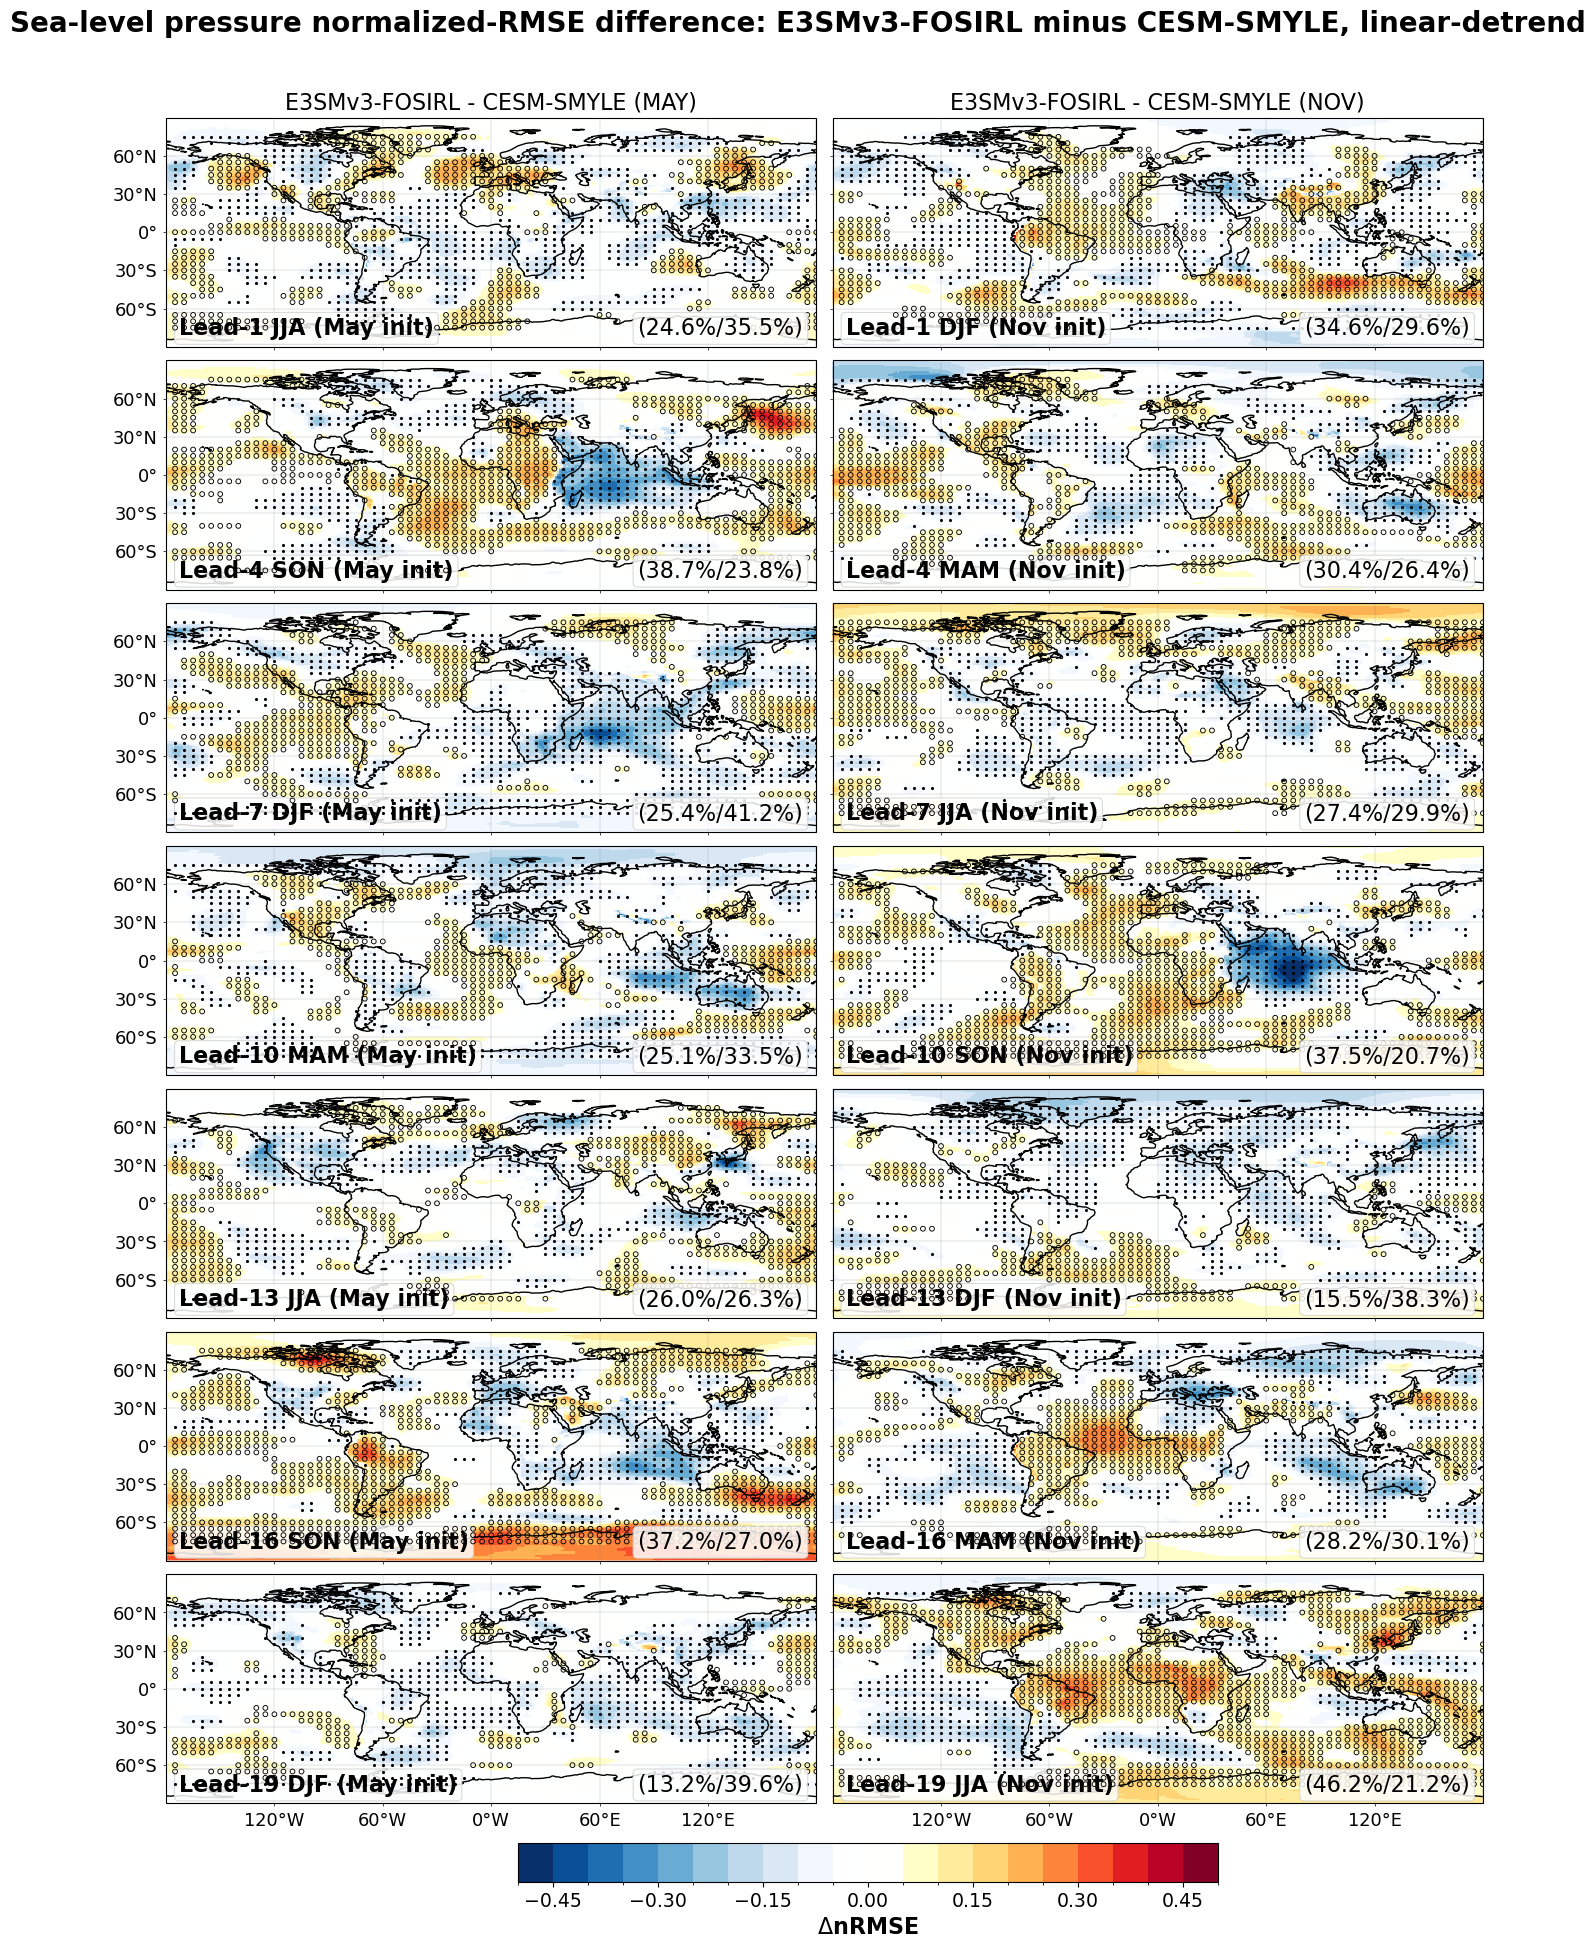

CPU times: user 10.9 s, sys: 927 ms, total: 11.8 s
Wall time: 11.3 s


In [63]:
%%time
# Plot fixed E3SMv3-FOSIRL nRMSE minus mean matched-size CESM-SMYLE nRMSE.
# Columns are initialization months: May, November.
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter
import matplotlib.ticker as mticker

compare_init_months_plot = sorted(
    set(e3sm_compare_skill_by_month)
    & set(smyle_compare_skill_by_month)
    & set(rmse_significance_by_month)
)
if not compare_init_months_plot:
    raise RuntimeError(
        "No common initialization months are available. Run the preceding "
        "finite-ensemble comparison cell first."
    )
print("Plotting initialization months:", compare_init_months_plot)

e3sm_compare_skilldiff_by_month = {
    m: e3sm_compare_skill_by_month[m] - smyle_compare_skill_by_month[m].mean("iteration")
    for m in compare_init_months_plot
}

# Use the normalized-RMSE-difference colorbar selected with `field` above.
diff_level_steps = np.diff(nrmse_diff_levels)
cmin = float(nrmse_diff_levels[0])
cmax = float(nrmse_diff_levels[-1])
ci = float(diff_level_steps[0])
latlim = 80
symclr = "black"
marker_stride = 5
open_marker_size = 12
filled_marker_size = 5
marker_linewidth = 0.65

compare_fontz = 16
compare_panel_title_size = compare_fontz
compare_lead_label_size = compare_fontz * 1.0
compare_lat_lon_label_size = compare_fontz * 0.8
compare_suptitle_size = compare_fontz * 1.25
compare_colorbar_label_size = compare_fontz
compare_colorbar_tick_size = compare_fontz * 0.85
compare_fweight = "bold"

plot_nlead = min(7, *(e3sm_compare_skilldiff_by_month[m].sizes["L"] for m in compare_init_months_plot))
nrows = plot_nlead
ncols = len(compare_init_months_plot)
proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(7 * ncols, 2.8 * nrows))
cntr = None

area = destgrid.area
valid_area = xr.where(abs(destgrid.lat) < latlim, area, 0)
valid_area_sum = valid_area.sum()
lon2d, lat2d = np.meshgrid(destgrid.lon, destgrid.lat)

for i in range(plot_nlead):
    for j, compare_init_month in enumerate(compare_init_months_plot):
        smyle_skill = smyle_compare_skill_by_month[compare_init_month]
        skilldiff = e3sm_compare_skilldiff_by_month[compare_init_month]
        significance = rmse_significance_by_month[compare_init_month]
        lead = int(smyle_skill.L.values[i])
        leadstr = lead_label(compare_init_month, lead)
        init_label = init_month_names.get(compare_init_month, f"{compare_init_month:02d}")
        title = (
            f"E3SMv3-FOSIRL - CESM-SMYLE ({init_label})"
            if i == 0 else ""
        )
        subplot = i * ncols + j + 1

        ax, cntr = maps.map_pcolor_global_subplot(
            fig,
            skilldiff.rmse.isel(L=i),
            smyle_skill.lon,
            smyle_skill.lat,
            ci, cmin, cmax,
            title,
            nrows, ncols, subplot,
            proj, cmap="blue2red", cutoff=0.5,
            fontsize=compare_panel_title_size,
        )

        ax.set_xticks([-120, -60, 0, 60, 120], crs=ccrs.PlateCarree())
        ax.set_yticks([-60, -30, 0, 30, 60], crs=ccrs.PlateCarree())
        ax.xaxis.set_major_formatter(LongitudeFormatter(zero_direction_label=True))
        ax.yaxis.set_major_formatter(LatitudeFormatter())
        ax.tick_params(
            labelsize=compare_lat_lon_label_size,
            length=2.5,
            width=0.5,
            top=False,
            right=False,
            labelbottom=(i == nrows - 1),
            labelleft=(j == 0),
        )
        ax.gridlines(
            crs=ccrs.PlateCarree(),
            linewidth=0.35,
            color="0.35",
            alpha=0.35,
            linestyle="-",
            draw_labels=False,
        )

        ax.text(
            0.02, 0.03, leadstr,
            transform=ax.transAxes,
            ha="left",
            va="bottom",
            fontsize=compare_lead_label_size,
            fontweight=compare_fweight,
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="lightgray", alpha=0.85, linewidth=0.8),
            zorder=10,
        )

        valid = ~skilldiff.rmse.isel(L=i).isnull()

        # Open circles: right-hand CESM-SMYLE robustly has lower nRMSE.
        bsmyle_better = significance["right_better"].isel(L=i).astype(bool) & valid
        tmparea = xr.where(bsmyle_better, area, 0)
        tmparea = xr.where(abs(destgrid.lat) < latlim, tmparea, 0)
        nbetter = float(tmparea.sum() / valid_area_sum)
        display_mask = np.asarray(bsmyle_better)[::marker_stride, ::marker_stride]
        display_lon = lon2d[::marker_stride, ::marker_stride]
        display_lat = lat2d[::marker_stride, ::marker_stride]
        display_mask &= abs(display_lat) < latlim
        ax.scatter(
            display_lon[display_mask], display_lat[display_mask],
            facecolor="none", edgecolor=symclr,
            s=open_marker_size, linewidth=marker_linewidth, zorder=10,
        )

        # Filled dots: left-hand E3SMv3-FOSIRL robustly has lower nRMSE.
        e3sm_better = significance["left_better"].isel(L=i).astype(bool) & valid
        tmparea = xr.where(e3sm_better, area, 0)
        tmparea = xr.where(abs(destgrid.lat) < latlim, tmparea, 0)
        nworse = float(tmparea.sum() / valid_area_sum)
        display_mask = np.asarray(e3sm_better)[::marker_stride, ::marker_stride]
        display_mask &= abs(display_lat) < latlim
        ax.scatter(
            display_lon[display_mask], display_lat[display_mask],
            facecolor=symclr, edgecolor=symclr,
            s=filled_marker_size, linewidth=0, zorder=10,
        )

        ax.text(
            0.98, 0.03,
            f"({nbetter * 100:3.1f}%/{nworse * 100:3.1f}%)",
            transform=ax.transAxes,
            ha="right",
            va="bottom",
            fontsize=compare_lead_label_size,
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="lightgray", alpha=0.85, linewidth=0.8),
            zorder=10,
        )

fig.suptitle(
    f"{cfg['plot_name']} normalized-RMSE difference: "
    "E3SMv3-FOSIRL minus CESM-SMYLE, linear-detrend",
    fontsize=compare_suptitle_size,
    fontweight=compare_fweight,
    y=0.995,
)
fig.tight_layout(rect=[0.0, 0.08, 1.0, 0.94])
fig.subplots_adjust(top=0.94, bottom=0.08, hspace=0.06, wspace=0.025)
cbar_ax = fig.add_axes([0.3, 0.04, 0.5, 0.02])
cbar = fig.colorbar(cntr, cax=cbar_ax, orientation="horizontal")
cbar.set_ticks(nrmse_diff_ticks)
cbar.ax.xaxis.set_major_formatter(
    mticker.FormatStrFormatter(f"%.{nrmse_diff_decimals}f")
)
cbar.set_label(r"${\Delta}$nRMSE", fontsize=compare_colorbar_label_size, fontweight=compare_fweight)
cbar.ax.tick_params(labelsize=compare_colorbar_tick_size)

skilldiff_figname = figure_filename(field, "rmse_skill_diff")
skilldiff_figpath = FIGURE_OUTDIR / skilldiff_figname
mov.save_figure(
    fig, skilldiff_figpath,
    mode="",
    metric="leadtime_rmse_diff",
    title=f"Leadtime RMSE Difference: {field}",
    caption="RMSE difference between experiments",
    dpi=300,
)
print("Saved figure:", skilldiff_figpath)
plt.show()